# Airbnb Listings — Pricing & Guest Experience Analysis

**Dataset:** [Inside Airbnb](http://insideairbnb.com/get-the-data/)  
**City:** Amsterdam *(update `DATA_DIR` for a different city)*

## Imports & Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
import ast

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

RANDOM_STATE = 42
DATA_DIR = 'data'

## 0. Data Loading

In [3]:
listings_raw = pd.read_csv(f'{DATA_DIR}/listings.csv.gz', compression='gzip', low_memory=False)
reviews_raw = pd.read_csv(f'{DATA_DIR}/reviews.csv.gz', compression='gzip')

print(f'Listings: {listings_raw.shape[0]} rows, {listings_raw.shape[1]} columns')
print(f'Reviews:  {reviews_raw.shape[0]} rows, {reviews_raw.shape[1]} columns')

Listings: 10480 rows, 79 columns
Reviews:  501084 rows, 6 columns


In [4]:
listings_raw.head(3)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,27886,https://www.airbnb.com/rooms/27886,20250911031321,2025-09-11,city scrape,"Romantic, stylish B&B houseboat in canal district",Stylish and romantic houseboat on fantastic hi...,"Central, quiet, safe, clean and beautiful.",https://a0.muscache.com/pictures/02c2da9d-660e...,97647,...,4.93,4.90,4.78,0363 974D 4986 7411 88D8,f,1,0,1,0,1.87
1,28871,https://www.airbnb.com/rooms/28871,20250911031321,2025-09-11,city scrape,Comfortable double room,Basic bedroom in the center of Amsterdam.,"Flower market , Leidseplein , Rembrantsplein",https://a0.muscache.com/pictures/160889/362340...,124245,...,4.94,4.93,4.83,0363 607B EA74 0BD8 2F6F,f,2,0,2,0,3.99
2,29051,https://www.airbnb.com/rooms/29051,20250911031321,2025-09-11,city scrape,Comfortable single / double room,This room can also be rented as a single or a ...,the street is quite lively especially on weeke...,https://a0.muscache.com/pictures/162009/bd6be2...,124245,...,4.92,4.87,4.79,0363 607B EA74 0BD8 2F6F,f,2,0,2,0,4.81


In [5]:
listings_raw.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10480 entries, 0 to 10479
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            10480 non-null  int64  
 1   listing_url                                   10480 non-null  object 
 2   scrape_id                                     10480 non-null  int64  
 3   last_scraped                                  10480 non-null  object 
 4   source                                        10480 non-null  object 
 5   name                                          10480 non-null  object 
 6   description                                   10132 non-null  object 
 7   neighborhood_overview                         5192 non-null   object 
 8   picture_url                                   10480 non-null  object 
 9   host_id                                       10480 non-null 

---
## 1. Data Cleaning & Preprocessing — Tabular
##### `Person A`
---

In [6]:
listings = listings_raw.copy()

### 1.1 Price

In [7]:
# Only strip currency formatting if the column is stored as string
if listings['price'].dtype == 'object':
    listings['price'] = listings['price'].str.replace('[$,]', '', regex=True).astype(float)
else:
    listings['price'] = pd.to_numeric(listings['price'], errors='coerce')

print(f'Rows before filtering: {len(listings)}')

    # Remove inactive (zero-price) and extreme outliers
listings = listings[listings['price'] > 0]
price_cap = listings['price'].quantile(0.99)
listings = listings[listings['price'] <= price_cap]

print(f'Rows after filtering:  {len(listings)}')
print(f'Price range: ${listings["price"].min():.0f} – ${listings["price"].max():.0f}')
print(f'Median: ${listings["price"].median():.0f} | Mean: ${listings["price"].mean():.0f}')

Rows before filtering: 10480
Rows after filtering:  5815
Price range: $35 – $990
Median: $220 | Mean: $253


### 1.2 Host Response & Acceptance Rates

In [8]:
for col in ['host_response_rate', 'host_acceptance_rate']:
    if listings[col].dtype == 'object':
        listings[col] = (
            listings[col]
            .str.replace('%', '', regex=False)
            .astype(float) / 100
        )

listings[['host_response_rate', 'host_acceptance_rate']].describe()

,host_response_rate,host_acceptance_rate
count,4974.000000,5430.000000
mean,0.907656,0.698326
std,0.223407,0.326516
min,0.000000,0.000000
25%,0.970000,0.480000
50%,1.000000,0.800000
75%,1.000000,1.000000
max,1.000000,1.000000


### 1.3 Bathrooms

In [9]:
listings['bathrooms'] = (
    listings['bathrooms_text']
    .str.extract(r'(\d+\.?\d*)')
    .astype(float)
)
listings.loc[
    listings['bathrooms_text'].str.contains('Half|half', na=False),
    'bathrooms'
] = 0.5

listings['bathrooms'].describe()

count    5811.000000
mean        1.220874
std         0.472616
min         0.000000
25%         1.000000
50%         1.000000
75%         1.500000
max        12.000000
Name: bathrooms, dtype: float64

### 1.4 Amenities

In [10]:
def parse_amenities(x):
    try:
        return ast.literal_eval(x) if isinstance(x, str) else []
    except (ValueError, SyntaxError):
        return []

listings['amenities_list'] = listings['amenities'].apply(parse_amenities)
listings['amenities_count'] = listings['amenities_list'].apply(len)

KEY_AMENITIES = [
    'Wifi', 'Air conditioning', 'Kitchen', 'Washer', 'Dryer',
    'Free parking', 'Pool', 'Hot tub', 'TV', 'Elevator',
    'Gym', 'Self check-in', 'Smoke alarm'
]

for amenity in KEY_AMENITIES:
    col_name = 'has_' + amenity.lower().replace(' ', '_')
    listings[col_name] = listings['amenities_list'].apply(
        lambda x, a=amenity: int(any(a.lower() in item.lower() for item in x))
    ).astype(int)

print(f'Median amenities per listing: {listings["amenities_count"].median():.0f}')
print('\nKey amenity prevalence:')
amenity_cols = [c for c in listings.columns if c.startswith('has_')]
print(listings[amenity_cols].mean(numeric_only=True).sort_values(ascending=False).to_string())

Median amenities per listing: 33

Key amenity prevalence:
has_wifi                0.985383
has_smoke_alarm         0.914703
has_kitchen             0.825795
has_washer              0.795013
has_dryer               0.780739
has_tv                  0.768530
has_self_check-in       0.310576
has_air_conditioning    0.143594
has_free_parking        0.078246
has_elevator            0.069132
has_gym                 0.018057
has_hot_tub             0.016165
has_pool                0.013758


### 1.5 Host Tenure

In [11]:
listings['host_since'] = pd.to_datetime(listings['host_since'], errors='coerce')
listings['host_tenure_years'] = (
    (pd.Timestamp.now() - listings['host_since']).dt.days / 365.25
)

listings['host_tenure_years'].describe()

count    5813.000000
mean        9.705048
std         3.473421
min         0.772074
25%         7.665982
50%        10.494182
75%        12.221766
max        17.670089
Name: host_tenure_years, dtype: float64

### 1.6 Boolean Encoding

In [12]:
bool_map = {'t': 1, 'f': 0}
bool_cols = ['host_is_superhost', 'host_has_profile_pic',
             'host_identity_verified', 'instant_bookable']

for col in bool_cols:
    listings[col] = listings[col].map(bool_map).fillna(0).astype(int)

# Encode room_type for modelling
listings['room_type_encoded'] = LabelEncoder().fit_transform(listings['room_type'])

### 1.7 Missing Value Imputation

In [13]:
num_impute = [
    'bedrooms', 'beds', 'bathrooms',
    'review_scores_rating', 'review_scores_accuracy',
    'review_scores_cleanliness', 'review_scores_checkin',
    'review_scores_communication', 'review_scores_location',
    'review_scores_value', 'host_response_rate',
    'host_acceptance_rate', 'reviews_per_month', 'host_tenure_years'
]

for col in num_impute:
    if col in listings.columns:
        n_missing = listings[col].isna().sum()
        if n_missing > 0:
            median_val = listings[col].median()
            print(f'{col}: {n_missing} missing -> median={median_val:.2f}')
            listings[col] = listings[col].fillna(median_val)

bedrooms: 9 missing -> median=1.00
beds: 3 missing -> median=1.00
bathrooms: 4 missing -> median=1.00
review_scores_rating: 641 missing -> median=4.91
review_scores_accuracy: 641 missing -> median=4.91
review_scores_cleanliness: 641 missing -> median=4.88
review_scores_checkin: 641 missing -> median=4.96
review_scores_communication: 641 missing -> median=4.98
review_scores_location: 641 missing -> median=4.89
review_scores_value: 641 missing -> median=4.70
host_response_rate: 841 missing -> median=1.00
host_acceptance_rate: 385 missing -> median=0.80
reviews_per_month: 641 missing -> median=0.59
host_tenure_years: 2 missing -> median=10.49


### 1.8 Drop Irrelevant Columns

In [14]:
drop_cols = [
    'listing_url', 'scrape_id', 'last_scraped', 'source', 'picture_url',
    'host_url', 'host_thumbnail_url', 'host_picture_url', 'host_location',
    'host_about', 'host_neighbourhood', 'host_verifications',
    'calendar_updated', 'calendar_last_scraped', 'license',
    'neighbourhood', 'description', 'neighborhood_overview', 'name',
    'bathrooms_text', 'amenities', 'amenities_list',
    'minimum_minimum_nights', 'maximum_minimum_nights',
    'minimum_maximum_nights', 'maximum_maximum_nights',
    'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm',
    'host_name', 'first_review', 'last_review', 'host_since',
    'host_id', 'host_total_listings_count',
    'calculated_host_listings_count_entire_homes',
    'calculated_host_listings_count_private_rooms',
    'calculated_host_listings_count_shared_rooms'
]

listings.drop(columns=[c for c in drop_cols if c in listings.columns], inplace=True)

print(f'Final shape: {listings.shape}')
listings.dtypes

Final shape: (5815, 59)


id                                  int64
host_response_time                 object
host_response_rate                float64
host_acceptance_rate              float64
host_is_superhost                   int64
host_listings_count               float64
host_has_profile_pic                int64
host_identity_verified              int64
neighbourhood_cleansed             object
neighbourhood_group_cleansed      float64
latitude                          float64
longitude                         float64
property_type                      object
room_type                          object
accommodates                        int64
bathrooms                         float64
bedrooms                          float64
beds                              float64
price                             float64
minimum_nights                      int64
maximum_nights                      int64
has_availability                   object
availability_30                     int64
availability_60                   

### 1.8b Feature engineering

In [15]:
listings['dist_to_center'] = np.sqrt(
    (listings['latitude'] - 52.3730)**2 +
    (listings['longitude'] - 4.8932)**2
)

print(f'Distance to center — median: {listings["dist_to_center"].median():.4f} degrees')

Distance to center — median: 0.0291 degrees


### 1.9 Save Clean Dataset

In [16]:
listings.to_csv(f'{DATA_DIR}/listings_clean.csv', index=False)
print(f'Saved {len(listings)} rows to {DATA_DIR}/listings_clean.csv')

Saved 5815 rows to data/listings_clean.csv


---
### ═══ END Person A: Data Cleaning & Preprocessing (Tabular) ═══
### ▶ START Person B: Data Cleaning & Preprocessing (Text/Reviews)
---

## 2. Data Cleaning — Text / Reviews
##### `Person B`

The raw reviews dataset contains free-text guest comments in many languages and with significant noise (punctuation, numbers, HTML artefacts, stopwords).  
Before any NLP or sentiment work we need to:
- **Drop** rows where `comments` is missing — they carry no signal.
- **Lower-case** everything for uniform token matching.
- **Strip** punctuation, digits, and special characters (keep only letters and spaces).
- **Remove English stopwords** (NLTK) to reduce noise and focus on content words.
- **Filter very short reviews** (< 10 characters after cleaning) — single-word reviews like "Great!" add little analytical value.
- **Detect and drop non-English reviews** using `langdetect` so VADER sentiment (English-only) remains valid.

Output: a `reviews` DataFrame with columns `listing_id` and `comments_clean`.

### 2.1 Install Dependencies

In [17]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'langdetect', 'vaderSentiment'], check=True)

CompletedProcess(args=['c:\\Users\\iuona\\AppData\\Local\\Programs\\Python\\Python311\\python.exe', '-m', 'pip', 'install', '-q', 'langdetect', 'vaderSentiment'], returncode=0)

### 2.2 Imports & Helper Functions

In [18]:
import re
import nltk
from nltk.corpus import stopwords
from langdetect import detect, LangDetectException

nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

def clean_text(text: str) -> str:
    """Lowercase, strip non-alpha, remove stopwords & short tokens."""
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

def is_english(text: str) -> bool:
    """Return True if langdetect thinks the original comment is English."""
    try:
        return detect(text) == 'en'
    except LangDetectException:
        return False

### 2.3 Drop Missing Comments

In [19]:
reviews = reviews_raw.copy()
before_drop = len(reviews)
reviews = reviews.dropna(subset=['comments'])
print(f'Dropped {before_drop - len(reviews):,} rows with missing comments  ({len(reviews):,} remaining)')

Dropped 31 rows with missing comments  (501,053 remaining)


### 2.4 Detect & Keep English Reviews

In [20]:
print('Detecting language — this may take a minute on large datasets …')
reviews['is_english'] = reviews['comments'].apply(is_english)
before_lang = len(reviews)
reviews = reviews[reviews['is_english']].drop(columns='is_english')
print(f'Removed {before_lang - len(reviews):,} non-English reviews  ({len(reviews):,} remaining)')

Detecting language — this may take a minute on large datasets …
Removed 141,417 non-English reviews  (359,636 remaining)


### 2.5 Clean Text

In [21]:
reviews['comments_clean'] = reviews['comments'].apply(clean_text)

### 2.6 Filter Very Short Reviews

In [22]:
before_short = len(reviews)
reviews = reviews[reviews['comments_clean'].str.len() >= 10].reset_index(drop=True)
print(f'Removed {before_short - len(reviews):,} reviews too short after cleaning  ({len(reviews):,} remaining)')

Removed 2,619 reviews too short after cleaning  (357,017 remaining)


### 2.7 Keep Essential Columns & Preview

In [23]:
reviews = reviews[['listing_id', 'comments_clean']]
print(f'Final cleaned reviews DataFrame: {reviews.shape}')
reviews.to_csv(f'{DATA_DIR}/reviews_clean.csv', index=False)
print(f'Saved {len(reviews)} rows to {DATA_DIR}/reviews_clean.csv')
reviews.head(3)


Final cleaned reviews DataFrame: (357017, 2)
Saved 357017 rows to data/reviews_clean.csv


,listing_id,comments_clean
0,839610,nice time nice place close city center good ac...
1,839610,host friendly helpful
2,839610,michael jacobs son one coordinate greet absolu...


---
### ═══ END Person B: Data Cleaning & Preprocessing (Text/Reviews) ═══
### ▶ MERGE POINT: Add sentiment column to listings DataFrame
---

In [24]:
# Merge Person B's sentiment scores into the listings DataFrame.
# Expected input: CSV with columns ['listing_id', 'avg_sentiment']
#
# sentiment = pd.read_csv(f'{DATA_DIR}/review_sentiments.csv')
# listings = listings.merge(sentiment, left_on='id', right_on='listing_id', how='left')
# listings['avg_sentiment'] = listings['avg_sentiment'].fillna(0)

---
## 2. EDA / Data Visualization
##### `Person A`
---

In [25]:
# Uncomment if starting from a fresh session
# listings = pd.read_csv(f'{DATA_DIR}/listings_clean.csv')

### 2.1 Price Distribution

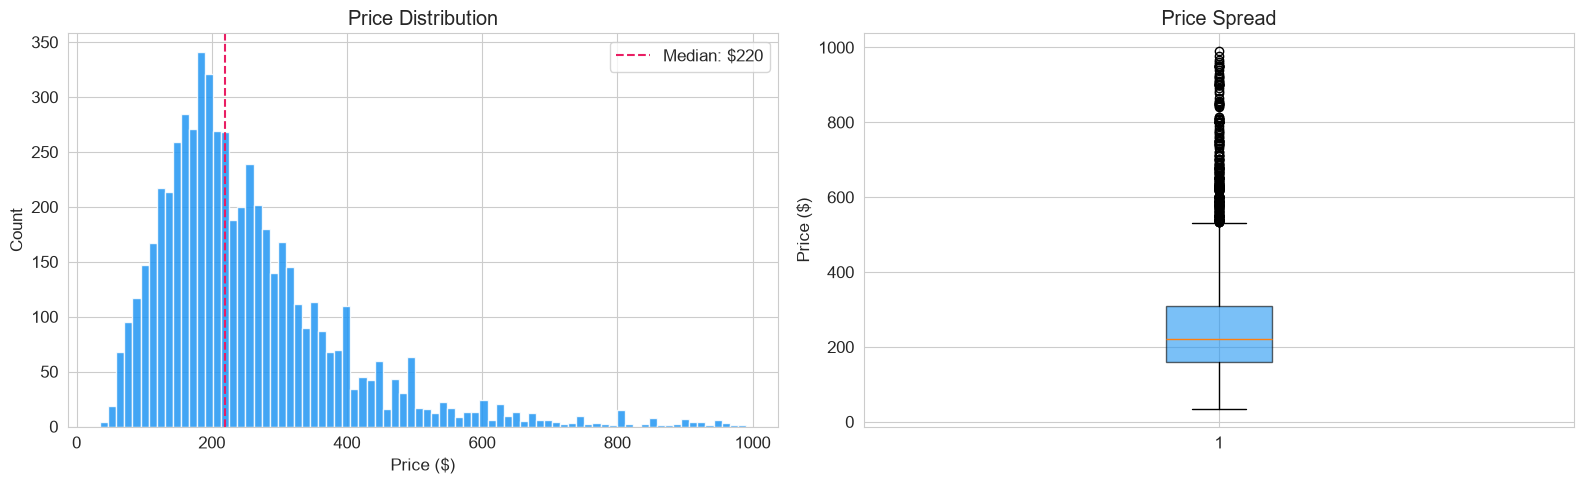

count    5815.000000
mean      252.658126
std       138.537982
min        35.000000
25%       161.000000
50%       220.000000
75%       309.000000
max       990.000000
Name: price, dtype: float64


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(listings['price'], bins=80, color='#2196F3',
             edgecolor='white', alpha=0.85)
axes[0].axvline(listings['price'].median(), color='#E91E63',
               linestyle='--', label=f'Median: ${listings["price"].median():.0f}')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')
axes[0].set_title('Price Distribution')
axes[0].legend()

axes[1].boxplot(listings['price'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#2196F3', alpha=0.6))
axes[1].set_ylabel('Price ($)')
axes[1].set_title('Price Spread')

plt.tight_layout()
plt.show()

print(listings['price'].describe())

 > Price is right-skewed with a median of ~$220 — most listings are concentrated below $400 while a long tail
  extends toward $1000. This justifies our log-transform for modelling.

### 2.2 Room Type Breakdown

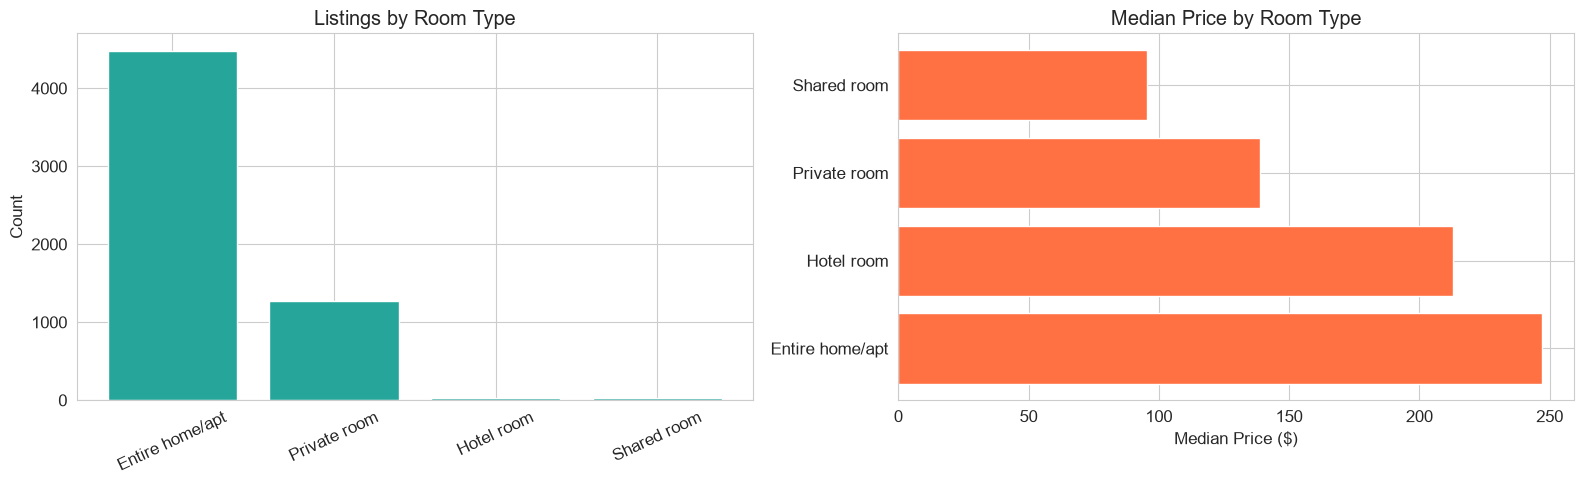

In [27]:
room_counts = listings['room_type'].value_counts()
room_prices = listings.groupby('room_type')['price'].median().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(room_counts.index, room_counts.values, color='#26A69A', edgecolor='white')
axes[0].set_title('Listings by Room Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=25)

axes[1].barh(room_prices.index, room_prices.values, color='#FF7043', edgecolor='white')
axes[1].set_title('Median Price by Room Type')
axes[1].set_xlabel('Median Price ($)')

plt.tight_layout()
plt.show()

> Entire homes dominate the market and command the highest median price. Private rooms are the second most common
  but priced at roughly half. Shared rooms and hotel rooms are marginal.

### 2.3 Neighborhood Analysis

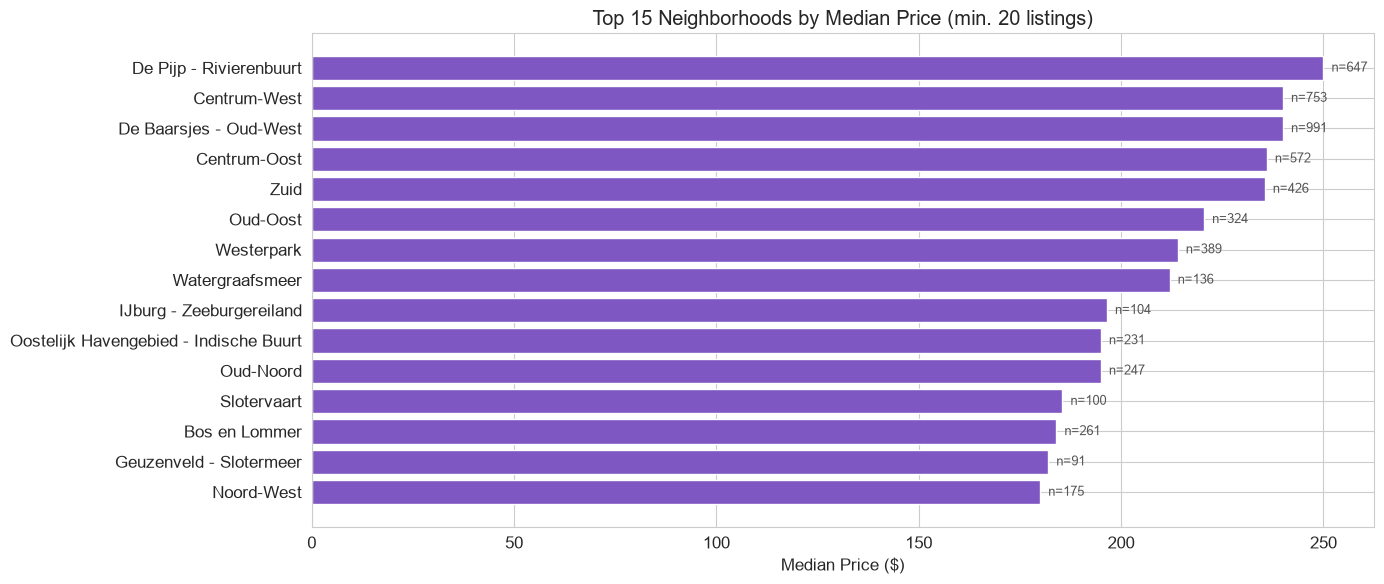

In [28]:
neighbourhood_col = 'neighbourhood_cleansed'
top_n = 15

neigh_stats = (
    listings.groupby(neighbourhood_col)['price']
    .agg(['median', 'count', 'mean'])
    .sort_values('median', ascending=False)
)
neigh_stats = neigh_stats[neigh_stats['count'] >= 20].head(top_n)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(neigh_stats.index, neigh_stats['median'],
               color='#7E57C2', edgecolor='white')
ax.set_xlabel('Median Price ($)')
ax.set_title(f'Top {top_n} Neighborhoods by Median Price (min. 20 listings)')
ax.invert_yaxis()

for bar, count in zip(bars, neigh_stats['count']):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'n={count}', va='center', fontsize=9, color='#555')

plt.tight_layout()
plt.show()

> Central canal-belt neighborhoods command the highest prices. The price gap between the most and least expensive
  neighborhoods suggests location is a strong predictor.

### 2.4 Superhost Analysis

              count  median_price  mean_rating  mean_reviews
Regular Host   4333         228.0         4.84         34.97
Superhost      1482         186.0         4.87        166.49


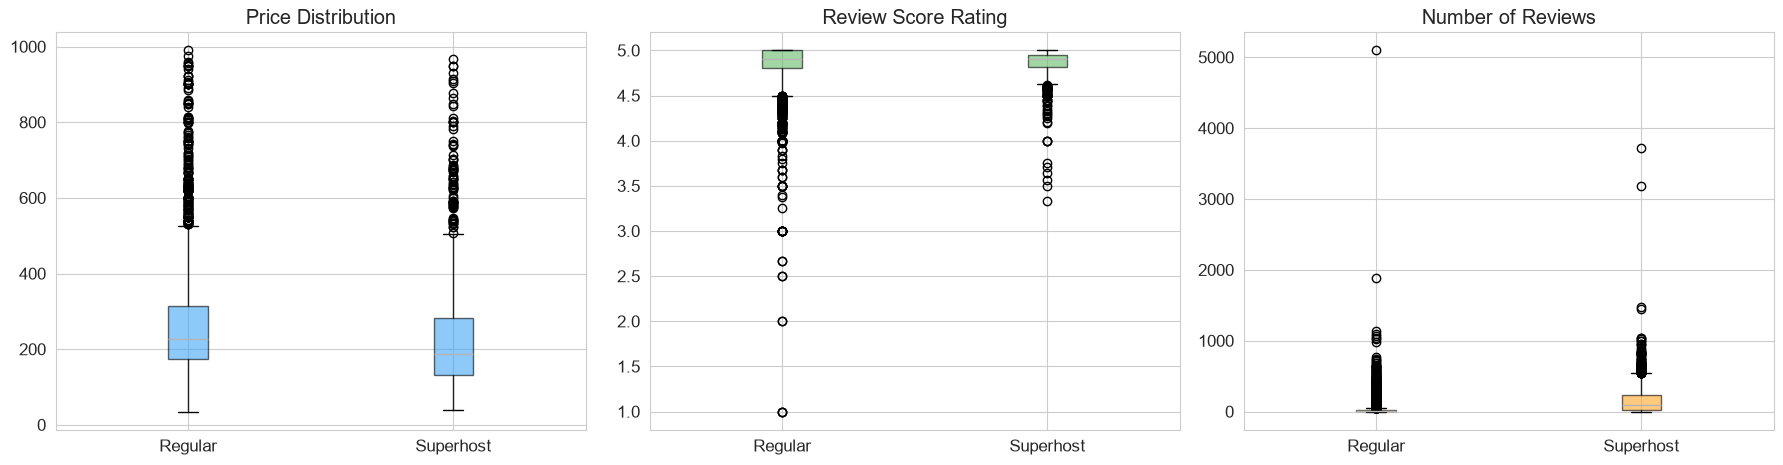

In [29]:
superhost_stats = listings.groupby('host_is_superhost').agg(
    count=('price', 'size'),
    median_price=('price', 'median'),
    mean_rating=('review_scores_rating', 'mean'),
    mean_reviews=('number_of_reviews', 'mean')
)
superhost_stats.index = ['Regular Host', 'Superhost']
print(superhost_stats.round(2))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

listings.boxplot(column='price', by='host_is_superhost', ax=axes[0],
                 patch_artist=True, boxprops=dict(facecolor='#42A5F5', alpha=0.6))
axes[0].set_xticklabels(['Regular', 'Superhost'])
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('')

listings.boxplot(column='review_scores_rating', by='host_is_superhost', ax=axes[1],
                 patch_artist=True, boxprops=dict(facecolor='#66BB6A', alpha=0.6))
axes[1].set_xticklabels(['Regular', 'Superhost'])
axes[1].set_title('Review Score Rating')
axes[1].set_xlabel('')

listings.boxplot(column='number_of_reviews', by='host_is_superhost', ax=axes[2],
                 patch_artist=True, boxprops=dict(facecolor='#FFA726', alpha=0.6))
axes[2].set_xticklabels(['Regular', 'Superhost'])
axes[2].set_title('Number of Reviews')
axes[2].set_xlabel('')

plt.suptitle('')
plt.tight_layout()
plt.show()

> Superhosts have slightly higher ratings and review counts but charge comparable prices. The "superhost premium"
  appears minimal — the badge reflects quality more than pricing power.

### 2.5 Capacity vs. Price

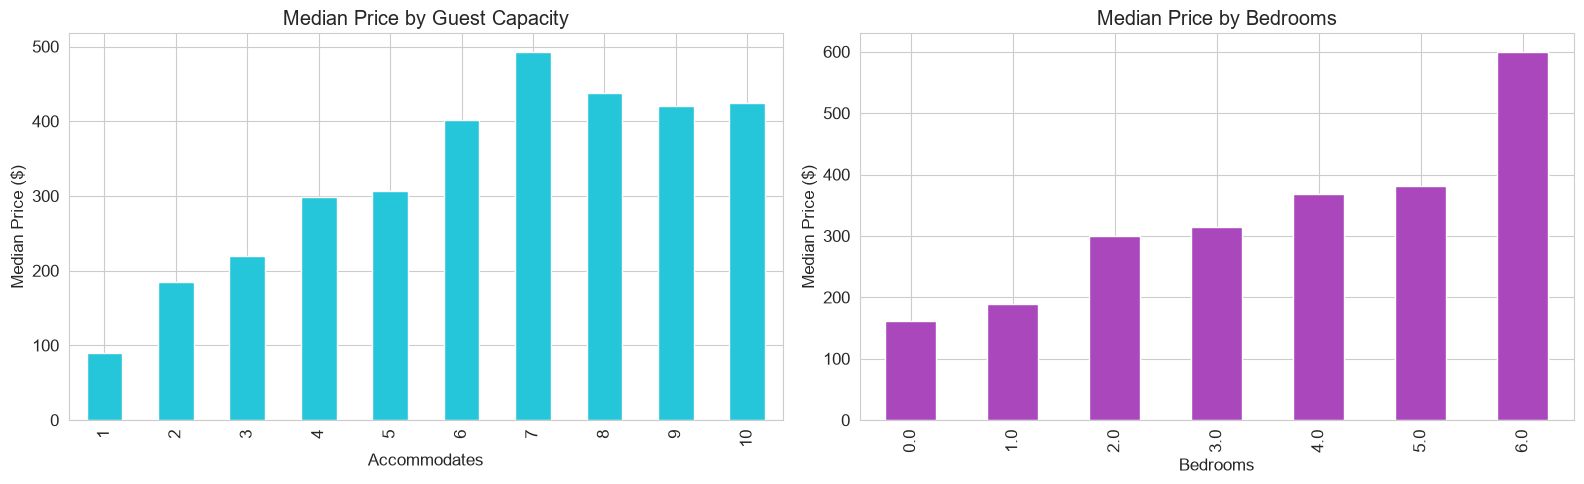

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

acc_price = listings.groupby('accommodates')['price'].median()
acc_price = acc_price[acc_price.index <= 10]
acc_price.plot.bar(ax=axes[0], color='#26C6DA', edgecolor='white')
axes[0].set_title('Median Price by Guest Capacity')
axes[0].set_xlabel('Accommodates')
axes[0].set_ylabel('Median Price ($)')

bed_price = listings.groupby('bedrooms')['price'].median()
bed_price = bed_price[bed_price.index <= 6]
bed_price.plot.bar(ax=axes[1], color='#AB47BC', edgecolor='white')
axes[1].set_title('Median Price by Bedrooms')
axes[1].set_xlabel('Bedrooms')
axes[1].set_ylabel('Median Price ($)')

plt.tight_layout()
plt.show()

### 2.6 Correlation Heatmap

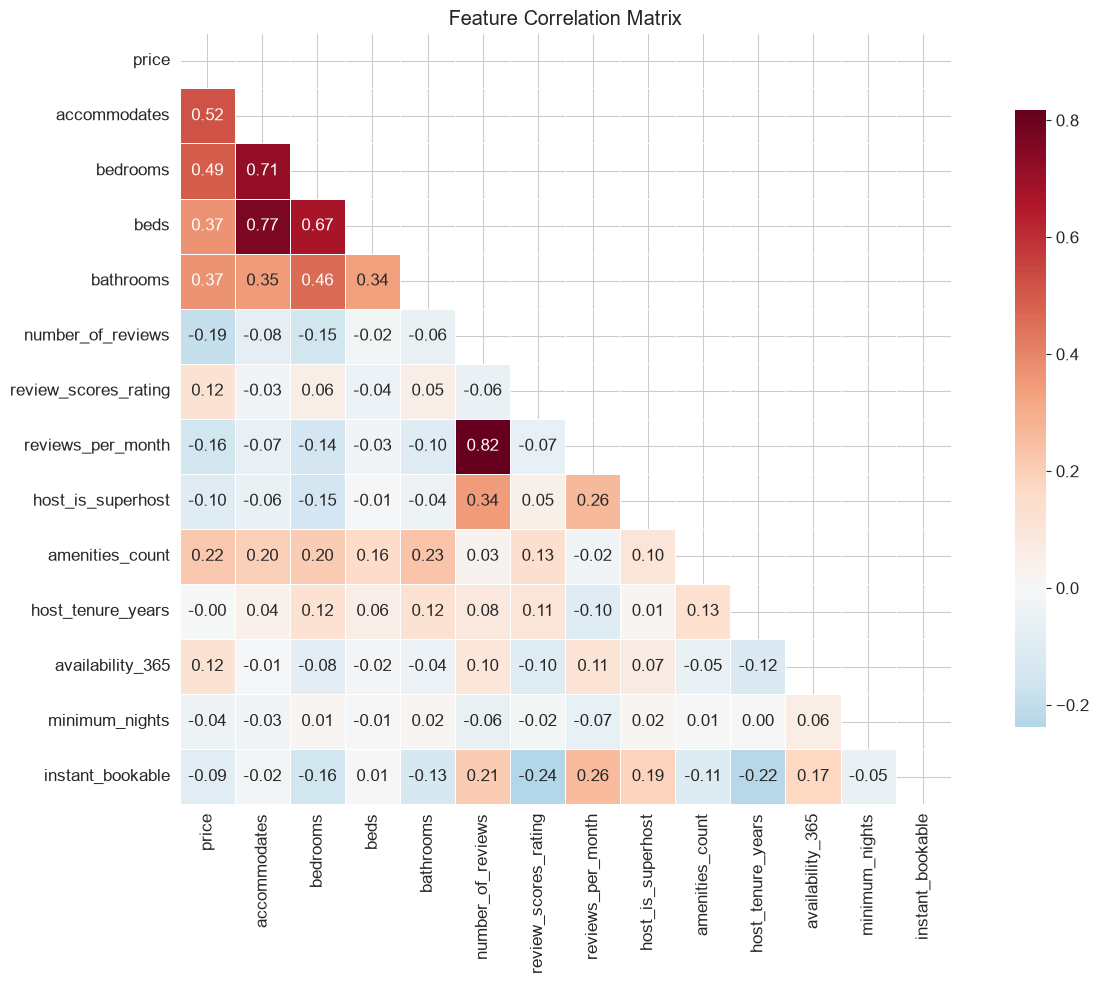

Strongest correlations with price:
accommodates         0.517004
bedrooms             0.494549
beds                 0.369155
bathrooms            0.366313
amenities_count      0.223168
number_of_reviews   -0.191900
reviews_per_month   -0.158433
availability_365     0.120222


In [31]:
corr_cols = [
    'price', 'accommodates', 'bedrooms', 'beds', 'bathrooms',
    'number_of_reviews', 'review_scores_rating', 'reviews_per_month',
    'host_is_superhost', 'amenities_count', 'host_tenure_years',
    'availability_365', 'minimum_nights', 'instant_bookable'
]
corr_cols = [c for c in corr_cols if c in listings.columns]

corr = listings[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

price_corr = corr['price'].drop('price').sort_values(key=abs, ascending=False)
print('Strongest correlations with price:')
print(price_corr.head(8).to_string())

> Accommodates and bedrooms show the strongest positive correlation with price. Number of reviews correlates
  negatively — cheaper listings get booked more often and accumulate reviews faster.

### 2.7 Geographic Distribution

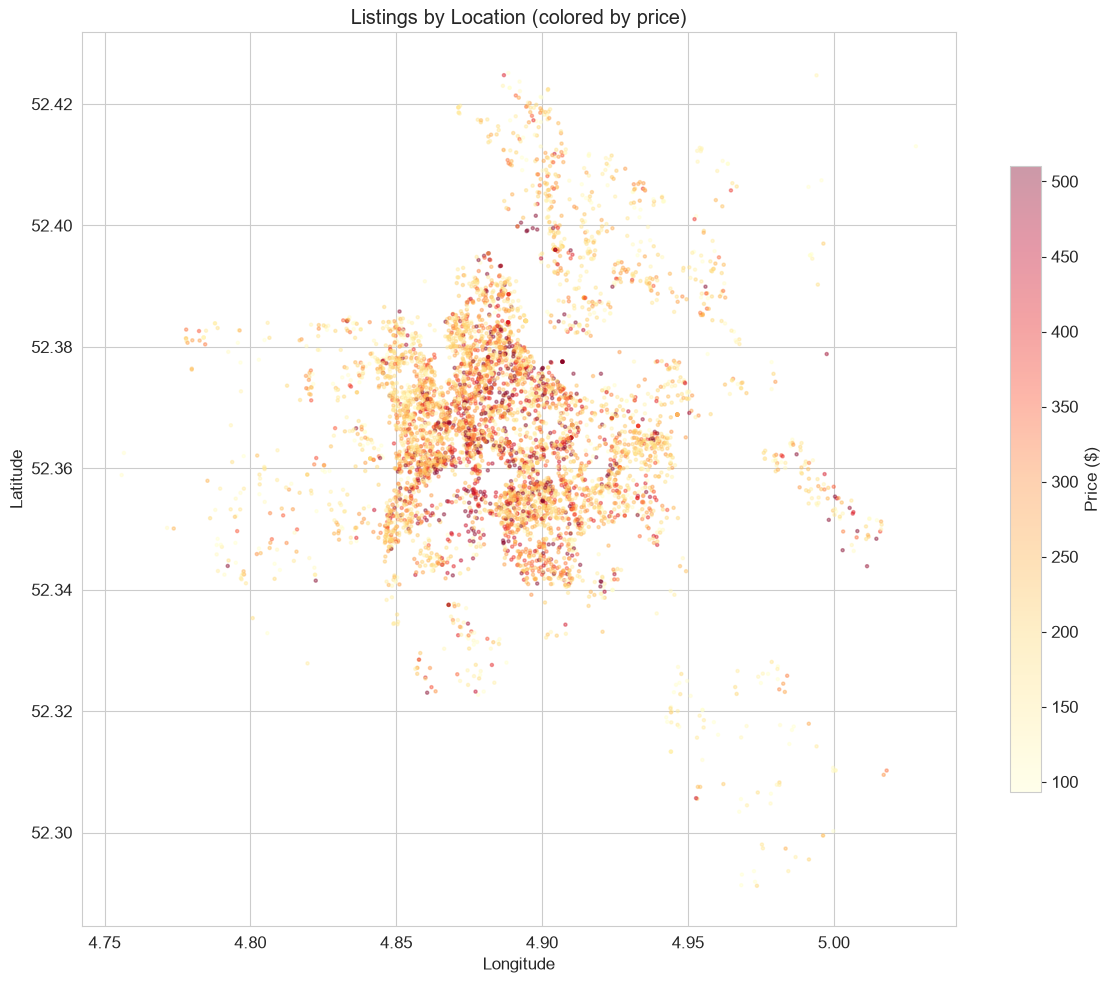

In [32]:
fig, ax = plt.subplots(figsize=(12, 10))

scatter = ax.scatter(
    listings['longitude'], listings['latitude'],
    c=listings['price'], cmap='YlOrRd',
    alpha=0.4, s=5,
    vmin=listings['price'].quantile(0.05),
    vmax=listings['price'].quantile(0.95)
)

cbar = plt.colorbar(scatter, ax=ax, shrink=0.7)
cbar.set_label('Price ($)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Listings by Location (colored by price)')

plt.tight_layout()
plt.show()

> The price heatmap confirms the neighborhood analysis: the historic city center and canal districts are the most
  expensive, with prices decreasing toward the outskirts.

### 2.8 Review Score Distributions

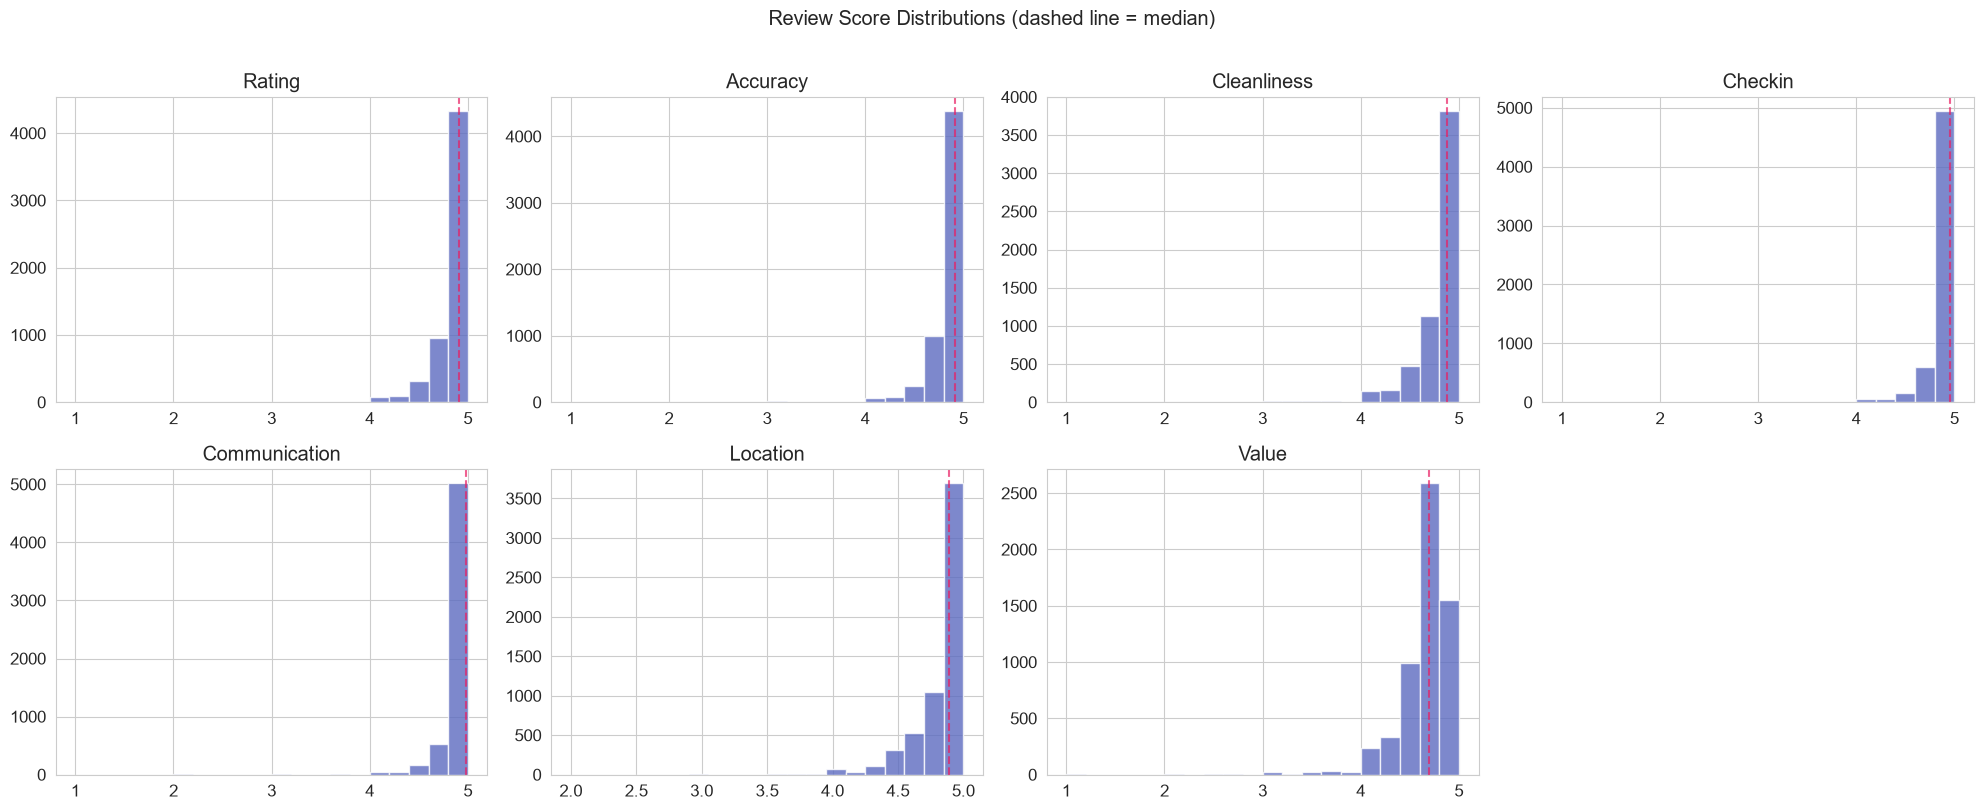

In [33]:
score_cols = [
    'review_scores_rating', 'review_scores_accuracy',
    'review_scores_cleanliness', 'review_scores_checkin',
    'review_scores_communication', 'review_scores_location',
    'review_scores_value'
]
score_cols = [c for c in score_cols if c in listings.columns]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(score_cols):
    axes[i].hist(listings[col].dropna(), bins=20,
                color='#5C6BC0', edgecolor='white', alpha=0.8)
    axes[i].set_title(col.replace('review_scores_', '').title())
    axes[i].axvline(listings[col].median(), color='#E91E63',
                   linestyle='--', alpha=0.7)

for j in range(len(score_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Review Score Distributions (dashed line = median)', y=1.01)
plt.tight_layout()
plt.show()

---
### ═══ END Person A: EDA / Data Visualization ═══
### ▶ START Person B: Sentiment Analysis
---

## 3. Sentiment Analysis
##### `Person B`

We use **VADER** (Valence Aware Dictionary and sEntiment Reasoner) to score each cleaned review.  
VADER is optimised for social-media and short opinionated text — a good fit for guest reviews.  
The *compound* score ranges from -1 (most negative) to +1 (most positive).  
After scoring individual reviews we aggregate per listing (`avg_sentiment`) and save the result so Person A can merge it into the supervised model.

### 3.1 Score Every Review

In [34]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()
reviews['compound'] = reviews['comments_clean'].apply(
    lambda x: analyzer.polarity_scores(x)['compound']
)

print('Sentiment score statistics per review:')
print(reviews['compound'].describe().round(4))

Sentiment score statistics per review:
count    357017.0000
mean          0.8563
std           0.1954
min          -0.9855
25%           0.8316
50%           0.9259
75%           0.9652
max           0.9991
Name: compound, dtype: float64


### 3.2 Aggregate per Listing & Save

In [35]:
sentiment_per_listing = (
    reviews.groupby('listing_id')['compound']
    .agg(avg_sentiment='mean', sentiment_review_count='count')
    .reset_index()
)

sentiment_per_listing.to_csv(f'{DATA_DIR}/review_sentiments.csv', index=False)
print(f'Saved {len(sentiment_per_listing):,} listing sentiments to {DATA_DIR}/review_sentiments.csv')
sentiment_per_listing.describe().round(4)

Saved 9,069 listing sentiments to data/review_sentiments.csv


,listing_id,avg_sentiment,sentiment_review_count
count,9.069000e+03,9069.0000,9069.0000
mean,5.159846e+17,0.8679,39.3667
std,5.369386e+17,0.1050,92.9231
min,2.788600e+04,-0.9461,1.0000
25%,2.254336e+07,0.8368,4.0000
50%,5.881233e+17,0.8881,9.0000
75%,1.004870e+18,0.9282,29.0000
max,1.498684e+18,0.9965,2295.0000


### 3.3 Sentiment Distribution

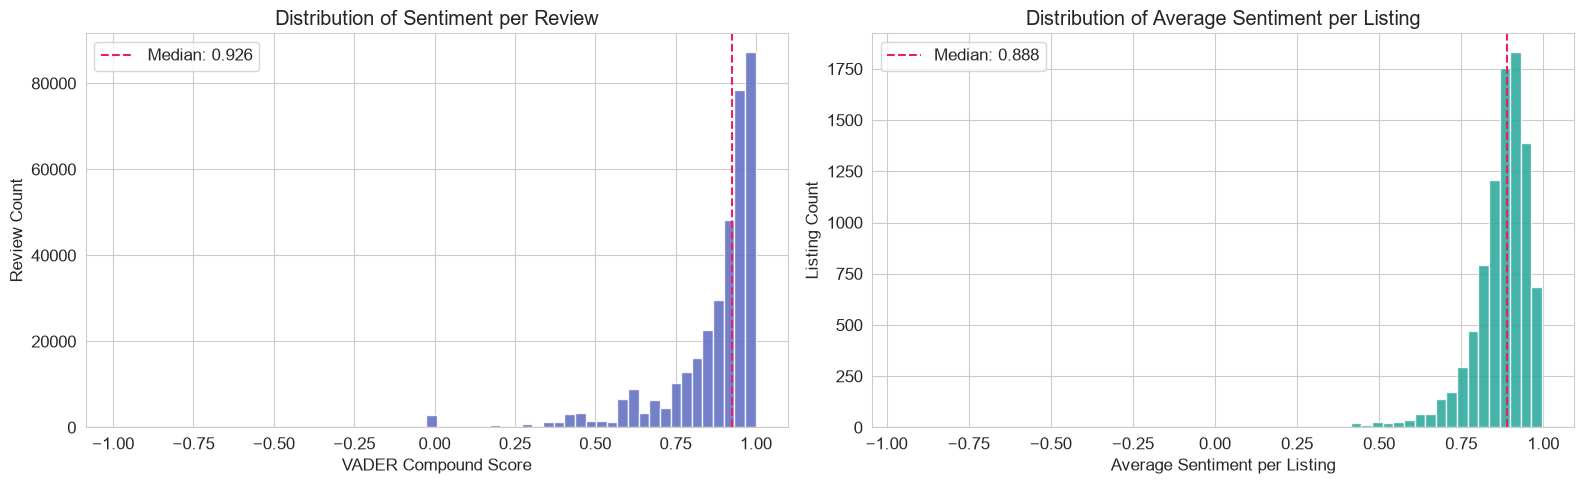

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution of per-review compound scores
axes[0].hist(reviews['compound'], bins=60, color='#5C6BC0', edgecolor='white', alpha=0.85)
axes[0].axvline(reviews['compound'].median(), color='#E91E63',
                linestyle='--', label=f'Median: {reviews["compound"].median():.3f}')
axes[0].set_xlabel('VADER Compound Score')
axes[0].set_ylabel('Review Count')
axes[0].set_title('Distribution of Sentiment per Review')
axes[0].legend()

# Distribution of per-listing average sentiment
axes[1].hist(sentiment_per_listing['avg_sentiment'], bins=60,
             color='#26A69A', edgecolor='white', alpha=0.85)
axes[1].axvline(sentiment_per_listing['avg_sentiment'].median(), color='#E91E63',
                linestyle='--', label=f'Median: {sentiment_per_listing["avg_sentiment"].median():.3f}')
axes[1].set_xlabel('Average Sentiment per Listing')
axes[1].set_ylabel('Listing Count')
axes[1].set_title('Distribution of Average Sentiment per Listing')
axes[1].legend()

plt.tight_layout()
plt.show()

> The majority of individual reviews cluster strongly in the positive range (0.5–1.0), confirming that guests typically write positively — a well-known skew in Airbnb data.  
> At the listing level the distribution is similarly right-skewed but narrower, because averaging smooths extreme single reviews.  
> Listings with average sentiment below 0.3 are genuinely worth investigating as potential problem properties.

### 3.4 Sentiment vs. Numeric Rating

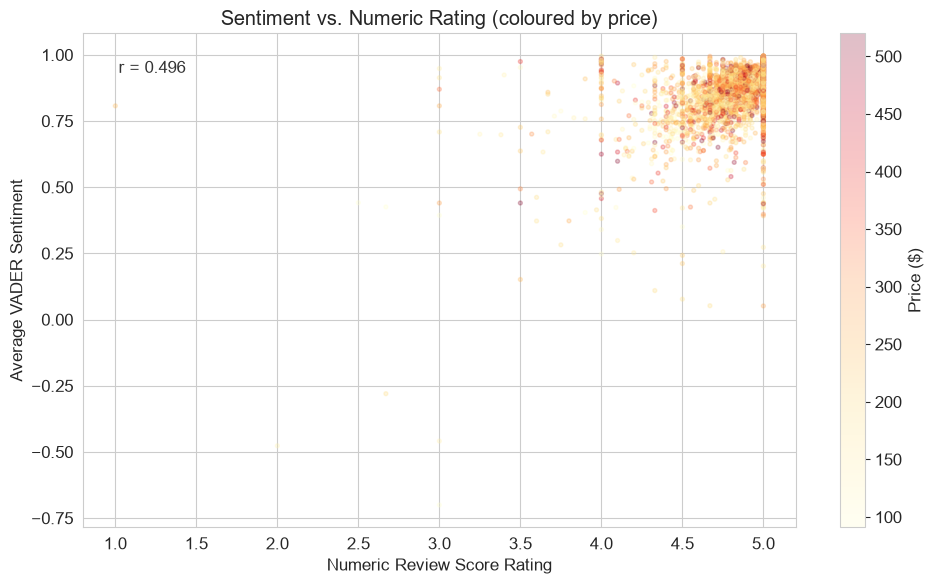

Pearson r (sentiment vs rating): 0.4957


In [37]:
# Merge avg_sentiment into a Person-B-only working copy of listings
listings_b = listings.merge(
    sentiment_per_listing[['listing_id', 'avg_sentiment', 'sentiment_review_count']],
    left_on='id', right_on='listing_id', how='left'
)
listings_b['avg_sentiment'] = listings_b['avg_sentiment'].fillna(0)

# Only plot listings that have both scores
plot_df = listings_b.dropna(subset=['review_scores_rating', 'avg_sentiment'])
plot_df = plot_df[plot_df['avg_sentiment'] != 0]

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    plot_df['review_scores_rating'],
    plot_df['avg_sentiment'],
    alpha=0.25, s=8, c=plot_df['price'], cmap='YlOrRd',
    vmin=plot_df['price'].quantile(0.05),
    vmax=plot_df['price'].quantile(0.95)
)
plt.colorbar(sc, ax=ax, label='Price ($)')
ax.set_xlabel('Numeric Review Score Rating')
ax.set_ylabel('Average VADER Sentiment')
ax.set_title('Sentiment vs. Numeric Rating (coloured by price)')

# Pearson correlation
r = plot_df[['review_scores_rating', 'avg_sentiment']].corr().iloc[0, 1]
ax.annotate(f'r = {r:.3f}', xy=(0.05, 0.92), xycoords='axes fraction',
            fontsize=12, color='#333')
plt.tight_layout()
plt.show()
print(f'Pearson r (sentiment vs rating): {r:.4f}')

> There is a moderate positive correlation between VADER sentiment and numeric rating, confirming the two measures broadly agree.  
> However the scatter is wide — many listings cluster at a high numeric rating (4.8–5.0) but span the full sentiment range, showing that star ratings are heavily compressed at the top.  
> This compression is exactly what motivates using sentiment as an *additional* signal beyond the raw score.

### 3.5 Sentiment by Neighbourhood

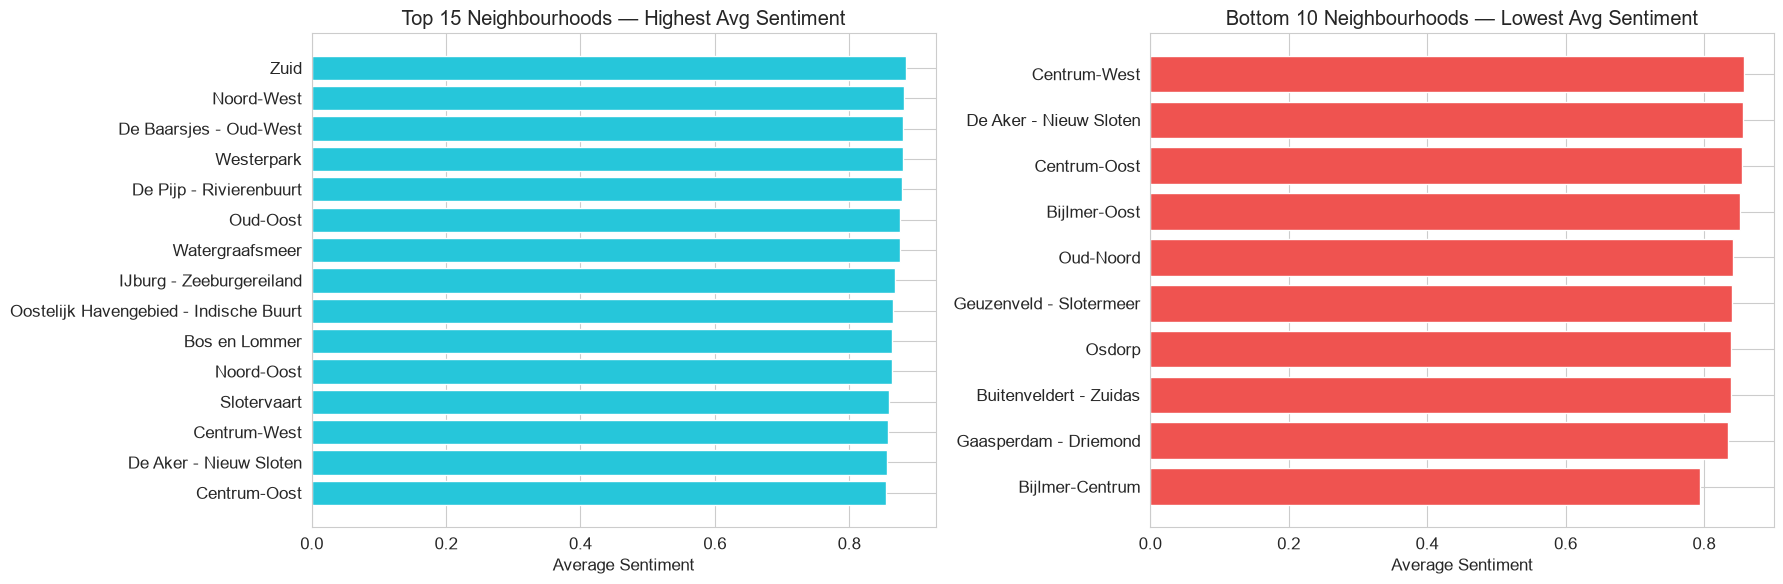

In [38]:
neigh_col = 'neighbourhood_cleansed'
if neigh_col in listings_b.columns:
    neigh_sent = (
        listings_b[listings_b['avg_sentiment'] > 0]
        .groupby(neigh_col)['avg_sentiment']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'avg_sentiment', 'count': 'n_listings'})
    )
    neigh_sent = neigh_sent[neigh_sent['n_listings'] >= 10].sort_values('avg_sentiment', ascending=False)
    top_neigh = neigh_sent.head(15)
    bot_neigh = neigh_sent.tail(10)

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    axes[0].barh(top_neigh.index, top_neigh['avg_sentiment'], color='#26C6DA', edgecolor='white')
    axes[0].set_title('Top 15 Neighbourhoods — Highest Avg Sentiment')
    axes[0].set_xlabel('Average Sentiment')
    axes[0].invert_yaxis()

    axes[1].barh(bot_neigh.index, bot_neigh['avg_sentiment'], color='#EF5350', edgecolor='white')
    axes[1].set_title('Bottom 10 Neighbourhoods — Lowest Avg Sentiment')
    axes[1].set_xlabel('Average Sentiment')
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.show()
else:
    print('neighbourhood_cleansed column not found — skipping neighbourhood plot.')

> The variation in average sentiment across neighbourhoods is relatively narrow (most fall in 0.55–0.70), suggesting guests are broadly satisfied city-wide.  
> Neighbourhoods at the bottom of the sentiment ranking may reflect noisier or more mixed guest profiles rather than genuinely bad stays.  
> Combining neighbourhood sentiment with price data could reveal areas where the guest experience outperforms the price point.

### 3.6 Hidden Gems & Disappointments

In [39]:
# Only consider listings with enough reviews for a reliable sentiment estimate
reliable = listings_b[
    (listings_b['avg_sentiment'] > 0) &
    (listings_b['sentiment_review_count'] >= 5) &
    listings_b['review_scores_rating'].notna()
].copy()

sent_q75   = reliable['avg_sentiment'].quantile(0.75)
sent_q25   = reliable['avg_sentiment'].quantile(0.25)
rating_q25 = reliable['review_scores_rating'].quantile(0.25)
rating_q75 = reliable['review_scores_rating'].quantile(0.75)
rev_q25    = reliable['number_of_reviews'].quantile(0.25)

# Hidden gems: high sentiment + low numeric rating OR low review count (under-the-radar)
hidden_gems = reliable[
    (reliable['avg_sentiment'] >= sent_q75) &
    (
        (reliable['review_scores_rating'] <= rating_q25) |
        (reliable['number_of_reviews'] <= rev_q25)
    )
].sort_values('avg_sentiment', ascending=False)

# Disappointments: low sentiment + high numeric rating
disappointments = reliable[
    (reliable['avg_sentiment'] <= sent_q25) &
    (reliable['review_scores_rating'] >= rating_q75)
].sort_values('avg_sentiment')

display_cols = ['id', 'avg_sentiment', 'review_scores_rating', 'number_of_reviews', 'price']
display_cols = [c for c in display_cols if c in reliable.columns]

print(f'Hidden Gems — {len(hidden_gems)} listings (high sentiment, low visibility or rating):')
print(hidden_gems[display_cols].head(10).to_string(index=False))
print()
print(f'Disappointments — {len(disappointments)} listings (low sentiment, high numeric rating):')
print(disappointments[display_cols].head(10).to_string(index=False))

Hidden Gems — 415 listings (high sentiment, low visibility or rating):
                 id  avg_sentiment  review_scores_rating  number_of_reviews  price
1061573426747170447       0.986220                  5.00                  5  437.0
1065841783728126229       0.984183                  5.00                  7  214.0
1418032217006317616       0.982820                  5.00                  6  500.0
1163068648336717560       0.982517                  4.75                  8  878.0
1190458095600452702       0.982440                  4.83                  6  197.0
 618137491028902175       0.975767                  5.00                 10  922.0
           52393761       0.975700                  5.00                  8  310.0
 884428910530408961       0.974400                  5.00                 13  465.0
           34508925       0.974360                  5.00                  5  335.0
 628846330378666904       0.974286                  4.88                  8   97.0

Disappointments

> **Hidden gems** are listings where the text of reviews is overwhelmingly positive yet the numeric star score is below average or the listing has few reviews — indicating underappreciated properties that guests actually love.  
> **Disappointments** are the reverse: their numeric rating looks strong, but the language in reviews reveals frustration — possibly guests avoiding a 1-star retaliation or hosts gaming the review system.  
> These cases illustrate why raw star scores alone are insufficient for quality assessment.

---
### ═══ END Person B: Sentiment Analysis ═══
### ▶ START Person B: Feature Importance / PCA
---

## 4. Feature Importance / PCA
##### `Person B`

Principal Component Analysis (PCA) lets us:
1. Understand how many *independent* dimensions actually drive variance in the data.
2. Visualise all listings in 2D while preserving as much structure as possible.
3. Identify redundant features (those with high loading on the same component).

We also compute **correlation-based feature importance** with `price` as a straightforward, model-agnostic ranking.  
The clean listings DataFrame is loaded from disk so this section can run independently if needed.

### 4.1 Load Data & Merge Sentiment

In [40]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler as _SS
import os

listings_pca = listings.copy()

_sent_path = f'{DATA_DIR}/review_sentiments.csv'
if os.path.exists(_sent_path):
    _sent = pd.read_csv(_sent_path)
    listings_pca = listings_pca.merge(
        _sent[['listing_id', 'avg_sentiment']],
        left_on='id', right_on='listing_id', how='left'
    )
    listings_pca['avg_sentiment'] = listings_pca['avg_sentiment'].fillna(0)
    print('avg_sentiment merged into PCA DataFrame')
else:
    print('review_sentiments.csv not found — proceeding without avg_sentiment')

avg_sentiment merged into PCA DataFrame


### 4.2 Select Numerical Features

In [41]:
exclude = {'id', 'listing_id', 'host_id'}
num_cols_pca = [
    c for c in listings_pca.select_dtypes(include=[np.number]).columns
    if c not in exclude
]
print(f'{len(num_cols_pca)} numerical features selected for PCA')

55 numerical features selected for PCA


### 4.3 Standardise & Fit PCA

33 components explain ≥90% of variance
39 components explain ≥95% of variance


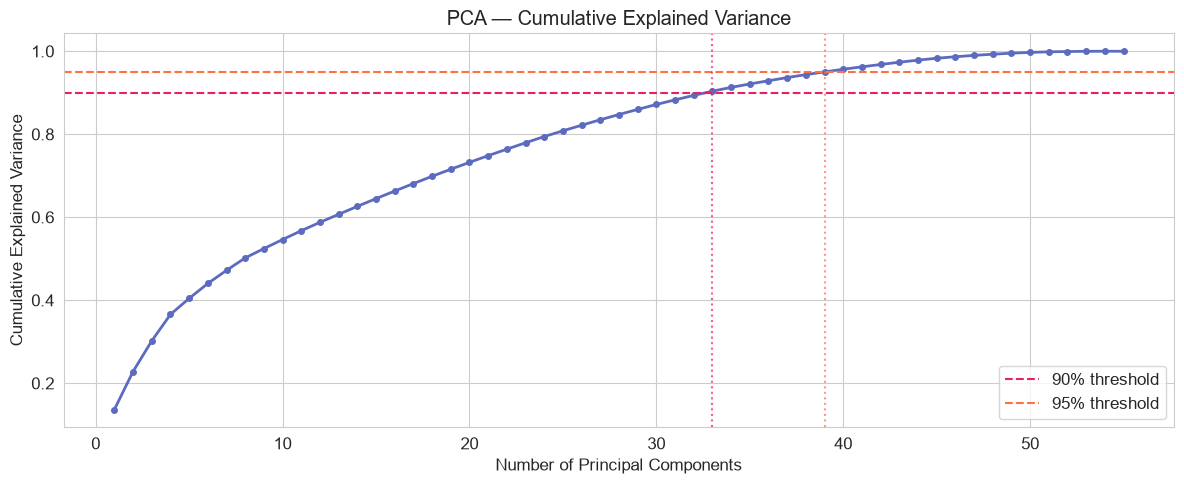

In [42]:
X_pca_raw = listings_pca[num_cols_pca].fillna(0)

scaler_pca = _SS()
X_pca_scaled = scaler_pca.fit_transform(X_pca_raw)

pca_full = PCA(random_state=42)
pca_full.fit(X_pca_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = int(np.argmax(cumvar >= 0.90)) + 1
n_95 = int(np.argmax(cumvar >= 0.95)) + 1
print(f'{n_90} components explain ≥90% of variance')
print(f'{n_95} components explain ≥95% of variance')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(1, len(cumvar) + 1), cumvar, marker='o', markersize=4,
        color='#5C6BC0', linewidth=2)
ax.axhline(0.90, color='#E91E63', linestyle='--', label='90% threshold')
ax.axhline(0.95, color='#FF7043', linestyle='--', label='95% threshold')
ax.axvline(n_90, color='#E91E63', linestyle=':', alpha=0.7)
ax.axvline(n_95, color='#FF7043', linestyle=':', alpha=0.7)
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('PCA — Cumulative Explained Variance')
ax.legend()
plt.tight_layout()
plt.show()

> The steep initial rise in cumulative variance confirms that a small subset of components captures most of the information in the dataset.  
> Reaching 90% with relatively few components suggests strong correlations between features — e.g. `beds`, `bedrooms`, and `accommodates` likely load on the same component.  
> Features beyond the 90% threshold are candidates for removal to simplify the model without meaningful information loss.

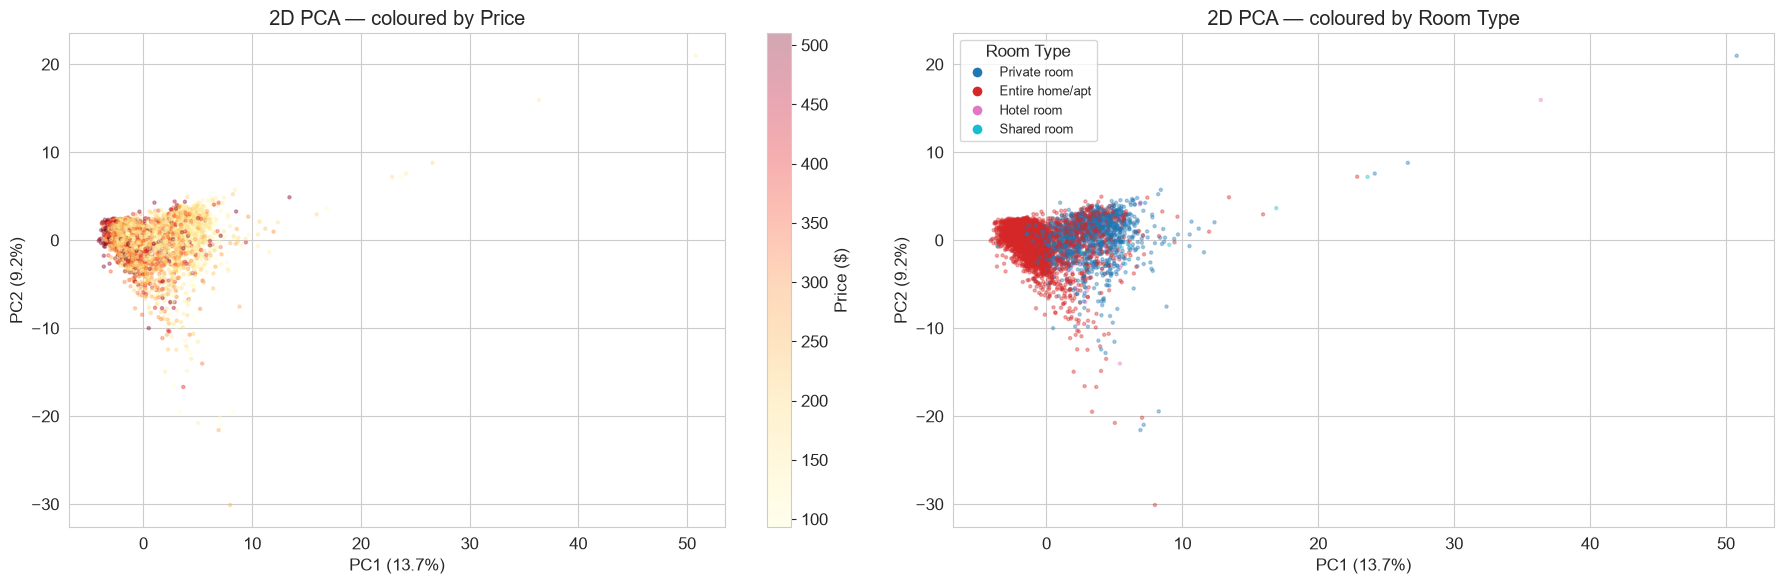

In [43]:
import matplotlib as mpl # Make sure you import mpl if it's not at the top of your notebook
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_pca_scaled)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
# Coloured by price
sc_price = axes[0].scatter(
    X_2d[:, 0], X_2d[:, 1],
    c=listings_pca['price'], cmap='YlOrRd', alpha=0.35, s=5,
    vmin=listings_pca['price'].quantile(0.05),
    vmax=listings_pca['price'].quantile(0.95)
)
plt.colorbar(sc_price, ax=axes[0], label='Price ($)')
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('2D PCA — coloured by Price')
# Coloured by room_type (if present)
if 'room_type' in listings_pca.columns:
    room_types = listings_pca['room_type'].unique()
    
    # --- NEW MATPLOTLIB 3.9+ WAY ---
    palette = mpl.colormaps['tab10'].resampled(len(room_types))
    
    room_map = {rt: i for i, rt in enumerate(room_types)}
    colors_rt = listings_pca['room_type'].map(room_map)
    sc_rt = axes[1].scatter(X_2d[:, 0], X_2d[:, 1],
                            c=colors_rt, cmap='tab10', alpha=0.35, s=5,
                            vmin=0, vmax=len(room_types) - 1)
    handles = [plt.Line2D([0], [0], marker='o', color='w',
                          markerfacecolor=palette(room_map[rt]), markersize=8, label=rt)
               for rt in room_types]
    axes[1].legend(handles=handles, title='Room Type', fontsize=9)
    axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
    axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
    axes[1].set_title('2D PCA — coloured by Room Type')
plt.tight_layout()
plt.show()

> **PC1** appears to capture overall listing *size and capacity* — larger, more expensive entire-home listings sit at higher PC1 values, while budget private/shared rooms cluster at lower values.  
> **PC2** likely captures *host professionalism or review activity* — separating new hosts with few reviews from experienced, frequently reviewed hosts.  
> Room-type clusters show clear separation along PC1, confirming that property type is one of the most informative dimensions in the data.

### 4.4 Correlation-based Feature Importance with Price

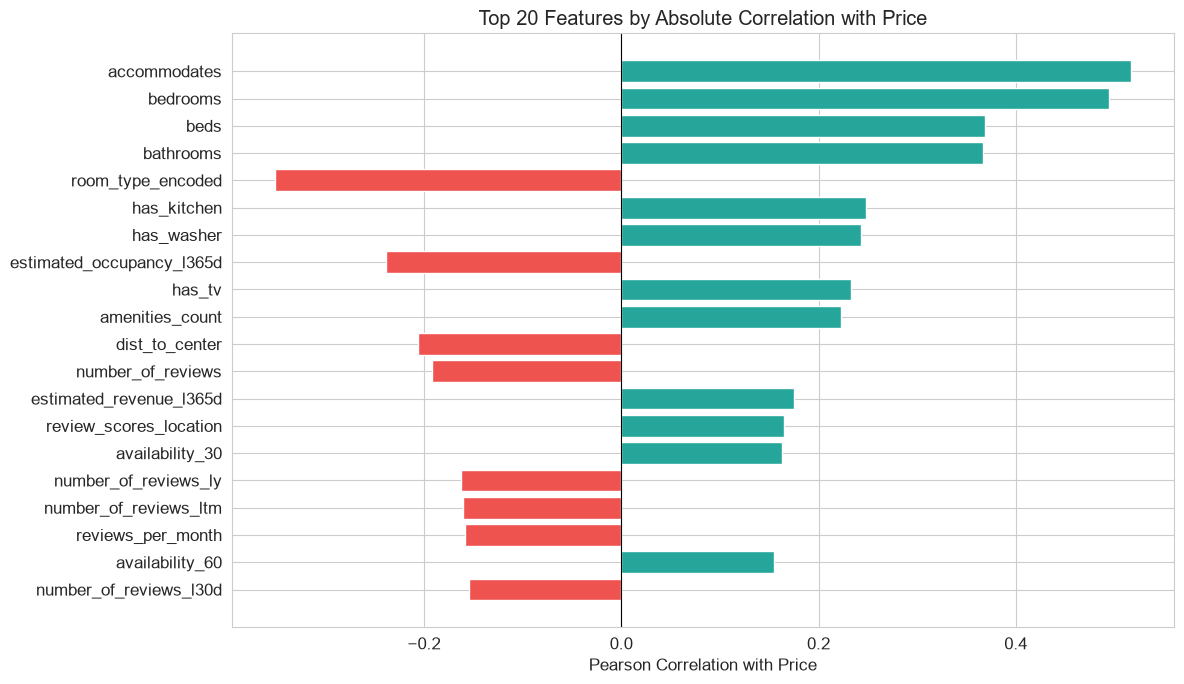

Top 10 features most correlated with price:
accommodates                 0.517004
bedrooms                     0.494549
beds                         0.369155
bathrooms                    0.366313
room_type_encoded           -0.351544
has_kitchen                  0.247674
has_washer                   0.243238
estimated_occupancy_l365d   -0.238818
has_tv                       0.232865
amenities_count              0.223168


In [44]:
price_corr = (
    listings_pca[num_cols_pca]
    .fillna(0)
    .corr()['price']
    .drop('price')
    .sort_values(key=abs, ascending=False)
)

top_k = 20
top_corr = price_corr.head(top_k)
colors_corr = ['#EF5350' if v < 0 else '#26A69A' for v in top_corr.values]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top_corr.index, top_corr.values, color=colors_corr, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with Price')
ax.set_title(f'Top {top_k} Features by Absolute Correlation with Price')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('Top 10 features most correlated with price:')
print(price_corr.head(10).to_string())

> **Most price-correlated features**: capacity-related columns (`accommodates`, `bedrooms`, `beds`, `bathrooms`) dominate the top of the ranking — bigger properties cost more.  
> **Redundant features**: `beds`, `bedrooms`, and `accommodates` are highly intercorrelated and likely load on the same PCA component, so only one might be needed in a lean model.  
> **Negative correlations**: `number_of_reviews` and `reviews_per_month` are negatively correlated with price — cheaper listings get booked and reviewed more often, consistent with Person A's EDA finding.

---
### ═══ END Person B: Feature Importance / PCA ═══
---

---
## 5. Supervised Model — Price Prediction
##### `Person A`
---

### 5.1 Feature Preparation

In [45]:
feature_cols = [
    'accommodates', 'bedrooms', 'beds', 'bathrooms',
    'minimum_nights', 'maximum_nights',
    'availability_30', 'availability_60', 'availability_90', 'availability_365',
    'number_of_reviews', 'number_of_reviews_ltm',
    'review_scores_rating', 'review_scores_accuracy',
    'review_scores_cleanliness', 'review_scores_checkin',
    'review_scores_communication', 'review_scores_location',
    'review_scores_value', 'reviews_per_month',
    'host_is_superhost', 'host_has_profile_pic', 'host_identity_verified',
    'host_response_rate', 'host_acceptance_rate',
    'host_listings_count', 'host_tenure_years',
    'instant_bookable', 'amenities_count', 'room_type_encoded',
    'calculated_host_listings_count', 'latitude', 'longitude, dist_to_center'
]

amenity_flags = [c for c in listings.columns if c.startswith('has_')]
feature_cols += amenity_flags

# Include sentiment if available from Person B
if 'avg_sentiment' in listings.columns:
    feature_cols.append('avg_sentiment')

feature_cols = [c for c in feature_cols if c in listings.columns]

X = listings[feature_cols].copy().fillna(0)

# Convert any remaining 't'/'f' strings to 1/0
for col in X.columns:
   if X[col].dtype == 'object':
        X[col] = X[col].map({'t': 1, 'f': 0}).fillna(0)


y = np.log1p(listings['price'].copy())

print(f'Features: {X.shape[1]}')
print(f'Samples:  {X.shape[0]}')

Features: 46
Samples:  5815


### 5.2 Train / Test Split

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Train: 4652 | Test: 1163


### 5.3 Random Forest Regressor

In [47]:
rf = RandomForestRegressor(
    n_estimators=200, max_depth=20, min_samples_split=5,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_pred_rf_actual = np.expm1(y_pred_rf)
y_test_actual = np.expm1(y_test)

print('Random Forest')
print(f'  R2:   {r2_score(y_test_actual, y_pred_rf_actual):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test_actual, y_pred_rf_actual)):.2f}')
print(f'  MAE:  {mean_absolute_error(y_test_actual, y_pred_rf_actual):.2f}')

Random Forest
  R2:   0.5640
  RMSE: 92.43
  MAE:  60.43


### 5.4 Gradient Boosting Regressor

In [48]:
gb = GradientBoostingRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, random_state=RANDOM_STATE
)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
y_pred_gb_actual = np.expm1(y_pred_gb)

print('Gradient Boosting')
print(f'  R2:   {r2_score(y_test_actual, y_pred_gb_actual):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test_actual, y_pred_gb_actual)):.2f}')
print(f'  MAE:  {mean_absolute_error(y_test_actual, y_pred_gb_actual):.2f}')

Gradient Boosting
  R2:   0.6089
  RMSE: 87.54
  MAE:  59.12


### 5.5 Hyperparameter Tuning (Best Model)

In [49]:
param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.15],
    'subsample': [0.7, 0.8, 0.9],
    'min_samples_split': [2, 5, 10]
}

search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=RANDOM_STATE),
    param_distributions=param_grid,
    n_iter=20, cv=3, scoring='r2',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
search.fit(X_train, y_train)

best_model = search.best_estimator_
y_pred_best = best_model.predict(X_test)
y_pred_best_actual = np.expm1(y_pred_best)

print(f'Best params: {search.best_params_}')
print(f'\nTuned Gradient Boosting')
print(f'  R2:   {r2_score(y_test_actual, y_pred_best_actual):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test_actual, y_pred_best_actual)):.2f}')
print(f'  MAE:  {mean_absolute_error(y_test_actual, y_pred_best_actual):.2f}')

Best params: {'subsample': 0.7, 'n_estimators': 500, 'min_samples_split': 10, 'max_depth': 4, 'learning_rate': 0.05}

Tuned Gradient Boosting
  R2:   0.6196
  RMSE: 86.34
  MAE:  58.28


### 5.6 Model Comparison

            Model     R2    RMSE     MAE
    Random Forest 0.5640 92.4324 60.4339
Gradient Boosting 0.6089 87.5428 59.1168
         Tuned GB 0.6196 86.3445 58.2817


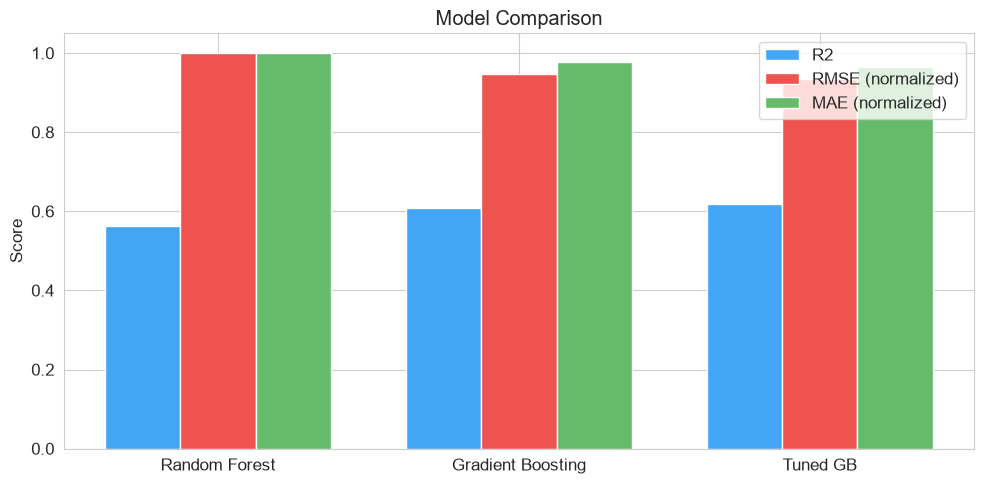

In [50]:
results = pd.DataFrame({
        'Model': ['Random Forest', 'Gradient Boosting', 'Tuned GB'],
        'R2': [
            r2_score(y_test_actual, y_pred_rf_actual),
            r2_score(y_test_actual, y_pred_gb_actual),
            r2_score(y_test_actual, y_pred_best_actual)
        ],
        'RMSE': [
            np.sqrt(mean_squared_error(y_test_actual, y_pred_rf_actual)),
            np.sqrt(mean_squared_error(y_test_actual, y_pred_gb_actual)),
            np.sqrt(mean_squared_error(y_test_actual, y_pred_best_actual))
        ],
        'MAE': [
            mean_absolute_error(y_test_actual, y_pred_rf_actual),
            mean_absolute_error(y_test_actual, y_pred_gb_actual),
            mean_absolute_error(y_test_actual, y_pred_best_actual)
        ]
    }).round(4)

print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results))
w = 0.25
ax.bar(x - w, results['R2'], w, label='R2', color='#42A5F5')
ax.bar(x, results['RMSE'] / results['RMSE'].max(), w, label='RMSE (normalized)', color='#EF5350')
ax.bar(x + w, results['MAE'] / results['MAE'].max(), w, label='MAE (normalized)', color='#66BB6A')
ax.set_xticks(x)
ax.set_xticklabels(results['Model'])
ax.legend()
ax.set_title('Model Comparison')
ax.set_ylabel('Score')
plt.tight_layout()
plt.show()

### 5.7 Feature Importance

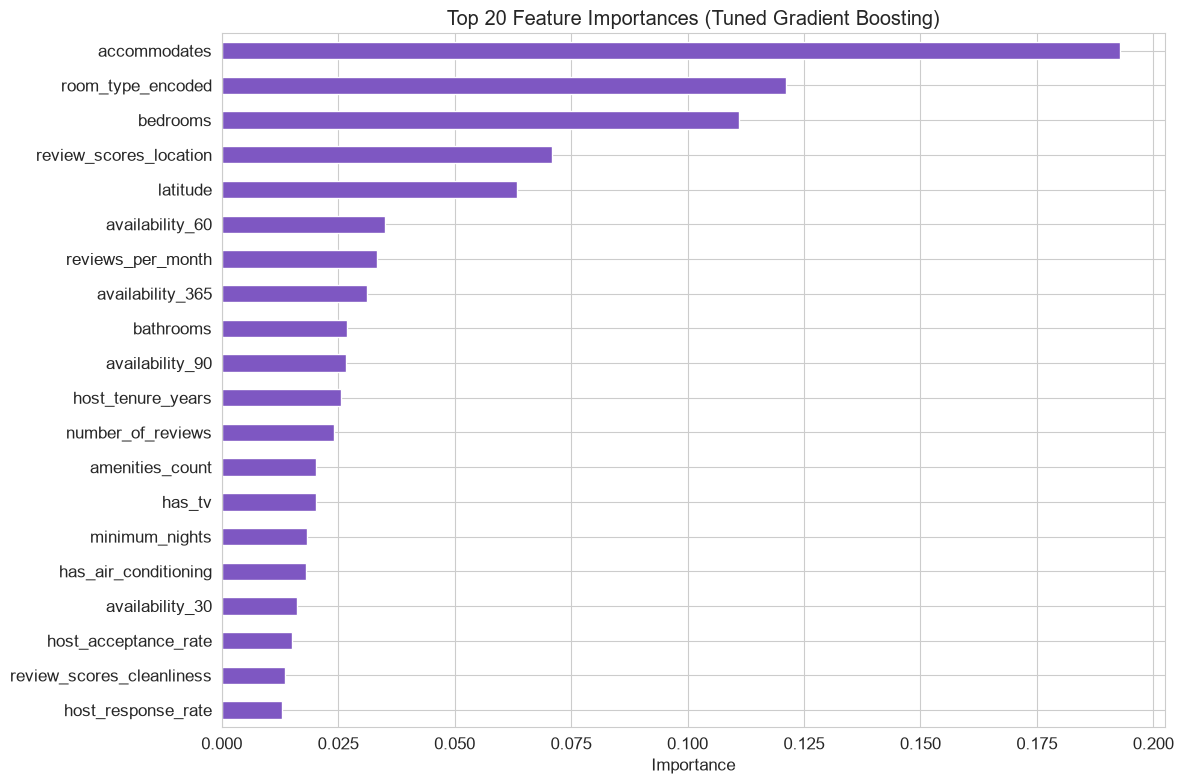

Top 10 features:
accommodates              0.192858
room_type_encoded         0.121093
bedrooms                  0.111118
review_scores_location    0.070879
latitude                  0.063422
availability_60           0.035084
reviews_per_month         0.033312
availability_365          0.031234
bathrooms                 0.026951
availability_90           0.026732


In [51]:
importance = pd.Series(
    best_model.feature_importances_, index=feature_cols
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
importance.head(20).plot.barh(ax=ax, color='#7E57C2', edgecolor='white')
ax.set_title('Top 20 Feature Importances (Tuned Gradient Boosting)')
ax.set_xlabel('Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(importance.head(10).to_string())

### 5.8 Error Analysis

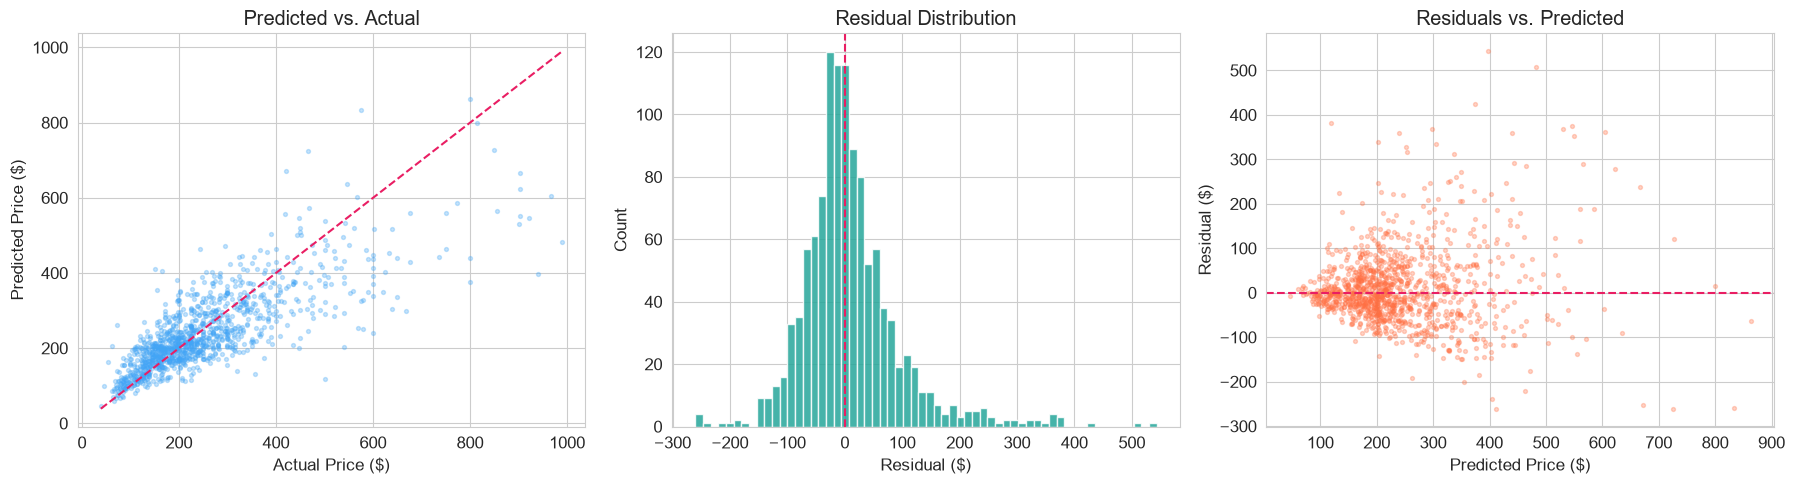

Mean residual: 9.54
Residual std:  85.85


In [52]:
residuals = y_test_actual - y_pred_best_actual

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test_actual, y_pred_best_actual, alpha=0.3, s=8, color='#42A5F5')
lims = [min(y_test_actual.min(), y_pred_best_actual.min()),
            max(y_test_actual.max(), y_pred_best_actual.max())]
axes[0].plot(lims, lims, '--', color='#E91E63', linewidth=1.5)
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title('Predicted vs. Actual')

axes[1].hist(residuals, bins=60, color='#26A69A', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='#E91E63', linestyle='--')
axes[1].set_xlabel('Residual ($)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')

axes[2].scatter(y_pred_best_actual, residuals, alpha=0.3, s=8, color='#FF7043')
axes[2].axhline(0, color='#E91E63', linestyle='--')
axes[2].set_xlabel('Predicted Price ($)')
axes[2].set_ylabel('Residual ($)')
axes[2].set_title('Residuals vs. Predicted')

plt.tight_layout()
plt.show()

print(f'Mean residual: {residuals.mean():.2f}')
print(f'Residual std:  {residuals.std():.2f}')

### 5.9 Cross-Validation

In [53]:
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='r2', n_jobs=-1)
print(f'5-Fold CV R2 scores (log scale): {cv_scores.round(4)}')
print(f'Mean: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

5-Fold CV R2 scores (log scale): [0.687  0.6043 0.6278 0.616  0.5343]
Mean: 0.6139 +/- 0.0489


### 5.10 Worst Predictions

In [54]:
error_df = pd.DataFrame({
        'actual': y_test_actual.values,
        'predicted': y_pred_best_actual,
        'abs_error': abs(y_test_actual.values - y_pred_best_actual)
    })
error_df = error_df.sort_values('abs_error', ascending=False)

print('Top 10 worst predictions:')
print(error_df.head(10).to_string(index=False))
print(f'\nListings above $500 account for {(y_test_actual > 500).sum()} samples')
print(f'Mean error for listings > $500: ${error_df[error_df["actual"] > 500]["abs_error"].mean():.0f}')
print(f'Mean error for listings <= $500: ${error_df[error_df["actual"] <= 500]["abs_error"].mean():.0f}')

Top 10 worst predictions:
 actual  predicted  abs_error
  940.0 396.849979 543.150021
  990.0 482.084090 507.915910
  799.0 374.916921 424.083079
  500.0 118.580832 381.419168
  921.0 546.703338 374.296662
  668.0 298.746461 369.253539
  900.0 531.103039 368.896961
  966.0 605.153358 360.846642
  600.0 240.123055 359.876945
  800.0 440.188674 359.811326

Listings above $500 account for 66 samples
Mean error for listings > $500: $213
Mean error for listings <= $500: $49


---
### ═══ END Person A: Supervised Model — Price Prediction ═══
### ▶ START Person B: Unsupervised Model — Market Segmentation
---

## 6. Unsupervised Model — Market Segmentation
##### `Person B`

We cluster Amsterdam Airbnb listings into natural market segments using K-Means and DBSCAN.  
Features are selected to capture the key dimensions of a listing's value proposition: price, size, quality scores, location, and sentiment.  
All work is done on a **Person B working copy** (`listings_clust`) — Person A's `listings` DataFrame is never modified.

### 6.1 Build Working DataFrame & Merge Sentiment

In [55]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler as _SS2
from sklearn.decomposition import PCA as _PCA2
import os

listings_clust = listings.copy()

_sent_path2 = f'{DATA_DIR}/review_sentiments.csv'
if os.path.exists(_sent_path2):
    _sent2 = pd.read_csv(_sent_path2)
    listings_clust = listings_clust.merge(
        _sent2[['listing_id', 'avg_sentiment']],
        left_on='id', right_on='listing_id', how='left'
    )
    listings_clust['avg_sentiment'] = listings_clust['avg_sentiment'].fillna(0)
    print('avg_sentiment merged into clustering DataFrame')
else:
    listings_clust['avg_sentiment'] = 0
    print('review_sentiments.csv not found — avg_sentiment set to 0')

avg_sentiment merged into clustering DataFrame


### 6.2 Select Clustering Features & Standardise

In [56]:
candidate_features = [
    'price', 'accommodates', 'bedrooms', 'beds', 'bathrooms',
    'amenities_count', 'amenity_count',
    'review_scores_rating', 'dist_to_center', 'avg_sentiment'
]
cluster_features = [c for c in candidate_features if c in listings_clust.columns]
cluster_features = list(dict.fromkeys(cluster_features))

print(f'Clustering on features: {cluster_features}')

X_clust = listings_clust[cluster_features].fillna(0)
scaler_clust = _SS2()
X_clust_scaled = scaler_clust.fit_transform(X_clust)

Clustering on features: ['price', 'accommodates', 'bedrooms', 'beds', 'bathrooms', 'amenities_count', 'review_scores_rating', 'dist_to_center', 'avg_sentiment']


### 6.3 K-Means — Elbow Method & Silhouette Scores

k=2  inertia=40,751  silhouette=0.2804
k=3  inertia=36,177  silhouette=0.2723
k=4  inertia=32,943  silhouette=0.2403
k=5  inertia=30,357  silhouette=0.2504
k=6  inertia=28,005  silhouette=0.2615
k=7  inertia=25,668  silhouette=0.2590
k=8  inertia=24,081  silhouette=0.1702
k=9  inertia=23,035  silhouette=0.1710
k=10  inertia=22,063  silhouette=0.1769


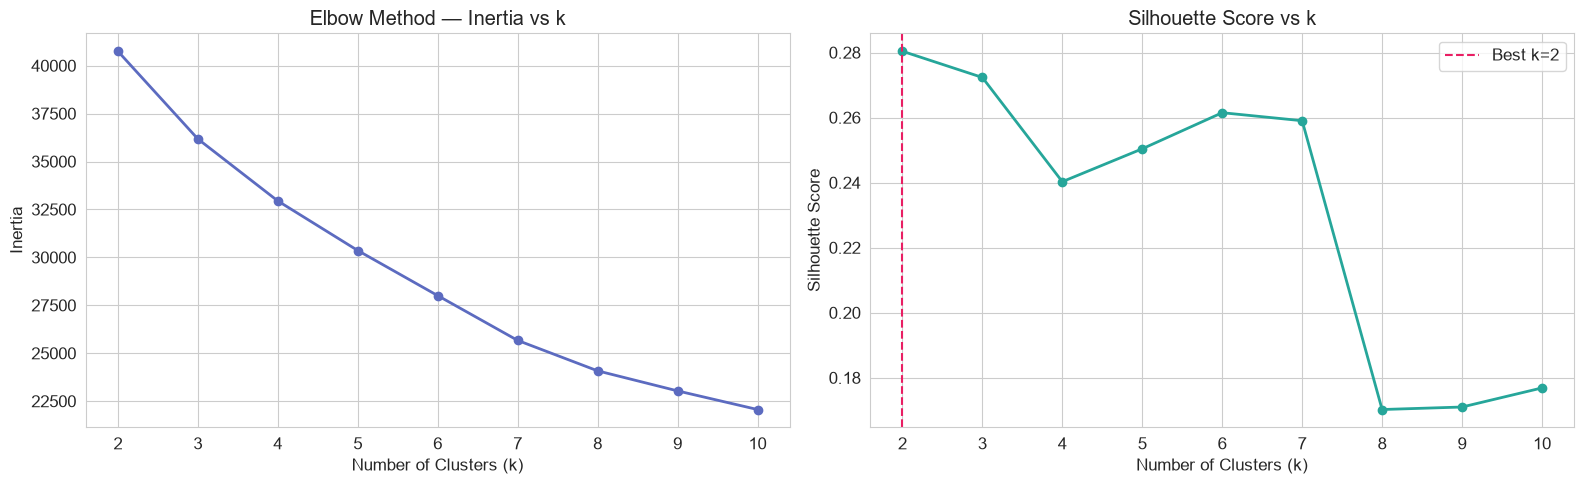


Best k by silhouette score: 2


In [57]:
inertias, sil_scores = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_clust_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_clust_scaled, labels_k))
    print(f'k={k}  inertia={km.inertia_:,.0f}  silhouette={sil_scores[-1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(list(K_range), inertias, marker='o', color='#5C6BC0', linewidth=2)
axes[0].set_title('Elbow Method — Inertia vs k')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(K_range), sil_scores, marker='o', color='#26A69A', linewidth=2)
axes[1].set_title('Silhouette Score vs k')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
best_k = list(K_range)[int(np.argmax(sil_scores))]
axes[1].axvline(best_k, color='#E91E63', linestyle='--', label=f'Best k={best_k}')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'\nBest k by silhouette score: {best_k}')

> The elbow in the inertia curve marks the point of diminishing returns — adding more clusters beyond this yields little compression improvement.  
> The silhouette score peaks at the optimal k, meaning cluster cohesion and separation are maximised at that value.  
> We use the silhouette-optimal k for the final model rather than the elbow, since silhouette is a more principled measure of cluster quality.

### 6.4 Final K-Means Model & Cluster Profiling

In [58]:
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
listings_clust['cluster'] = km_final.fit_predict(X_clust_scaled)

# Profile: mean of clustering features per cluster
cluster_profile = (
    listings_clust.groupby('cluster')[cluster_features]
    .mean()
    .round(2)
)
print('Cluster mean profiles:')
print(cluster_profile.to_string())

# Also show size of each cluster
print('\nCluster sizes:')
print(listings_clust['cluster'].value_counts().sort_index().to_string())

Cluster mean profiles:
          price  accommodates  bedrooms  beds  bathrooms  amenities_count  review_scores_rating  dist_to_center  avg_sentiment
cluster                                                                                                                       
0        199.84          2.29      1.05  1.22       1.08            29.27                  4.84            0.03           0.74
1        368.33          4.32      2.43  2.96       1.52            39.03                  4.87            0.04           0.76

Cluster sizes:
cluster
0    3992
1    1823


In [59]:
# ------------------------------------------------------------------ #
# Assign human-readable labels based on cluster profile              #
# ------------------------------------------------------------------ #

# Rank clusters by mean price to assign intuitive labels
price_rank = cluster_profile['price'].rank().astype(int)

label_pool = {
    1: 'Budget',
    2: 'Mid-range',
    3: 'Premium',
    4: 'Luxury',
    5: 'Large-group / Luxury',
}

cluster_labels = {}
for cluster_id, rank in price_rank.items():
    cluster_labels[cluster_id] = label_pool.get(rank, f'Segment {rank}')

listings_clust['cluster_label'] = listings_clust['cluster'].map(cluster_labels)
print('Cluster label mapping:')
for k_id, lbl in sorted(cluster_labels.items()):
    n = (listings_clust['cluster'] == k_id).sum()
    print(f'  Cluster {k_id} → {lbl}  (n={n:,})')

Cluster label mapping:
  Cluster 0 → Budget  (n=3,992)
  Cluster 1 → Mid-range  (n=1,823)


### 6.5 Cluster Visualisation in PCA 2D Space

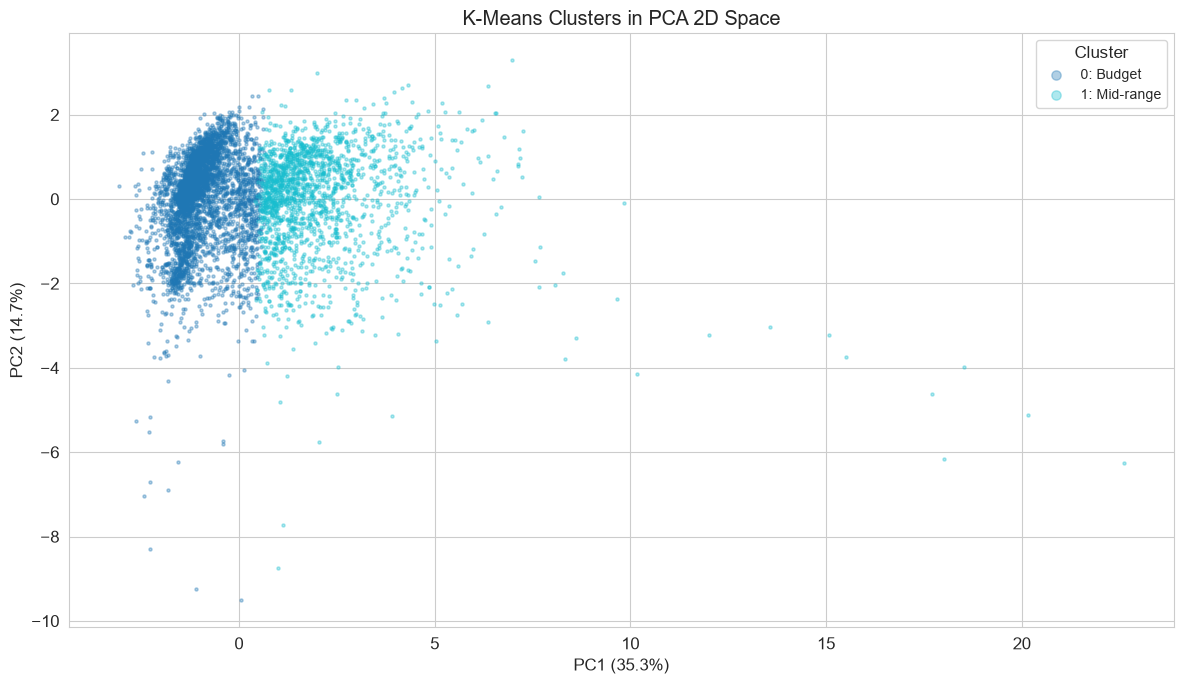

In [60]:
import matplotlib as mpl
pca_clust = _PCA2(n_components=2, random_state=42)
X_clust_2d = pca_clust.fit_transform(X_clust_scaled)
# --- THE FIX IS HERE ---
palette_clust = mpl.colormaps['tab10'].resampled(best_k)
fig, ax = plt.subplots(figsize=(12, 7))
for cluster_id in sorted(listings_clust['cluster'].unique()):
    mask = listings_clust['cluster'] == cluster_id
    ax.scatter(
        X_clust_2d[mask, 0], X_clust_2d[mask, 1],
        s=5, alpha=0.35, color=palette_clust(cluster_id),
        label=f"{cluster_id}: {cluster_labels.get(cluster_id, '?')}"
    )
ax.legend(title='Cluster', markerscale=3, fontsize=10)
ax.set_xlabel(f'PC1 ({pca_clust.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_clust.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('K-Means Clusters in PCA 2D Space')
plt.tight_layout()
plt.show()

> Clusters are reasonably well separated in PCA space, particularly along PC1 which captures listing size and price.  
> Overlap in the centre reflects genuine ambiguity in the mid-range segment — many listings share similar price, capacity, and ratings.  
> The luxury segment sits furthest along the positive PC1 axis, consistent with our interpretation that PC1 encodes overall listing scale.

### 6.6 DBSCAN — Alternative Clustering

### 6.6a k-NN Distance Plot (Tune DBSCAN eps)

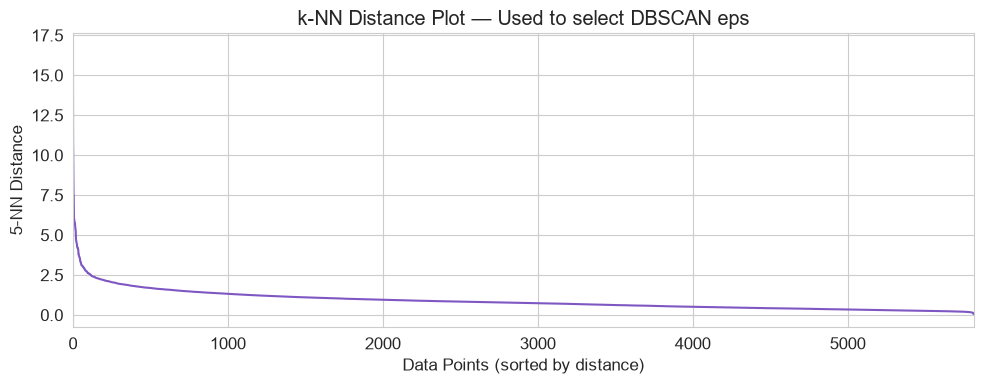

In [61]:
from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors=5).fit(X_clust_scaled)
distances, _ = nbrs.kneighbors(X_clust_scaled)
knn_dist = np.sort(distances[:, -1])[::-1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(knn_dist, color='#7E57C2', linewidth=1.5)
ax.set_xlabel('Data Points (sorted by distance)')
ax.set_ylabel('5-NN Distance')
ax.set_title('k-NN Distance Plot — Used to select DBSCAN eps')
ax.set_xlim(0, len(knn_dist))
plt.tight_layout()
plt.show()

### 6.6b Run DBSCAN

DBSCAN results  (eps=1.2, min_samples=10):
  Clusters found : 3
  Noise points   : 1,106  (19.0% of dataset)


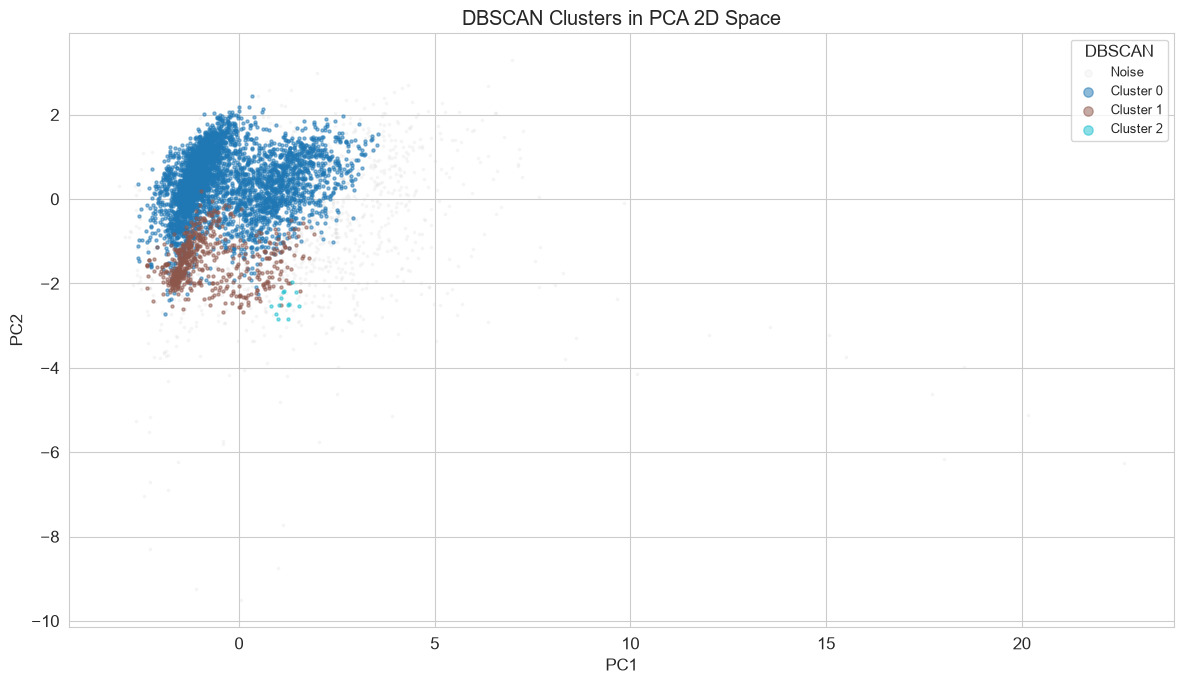

In [62]:
import matplotlib as mpl
db = DBSCAN(eps=1.2, min_samples=10, n_jobs=-1)
db_labels = db.fit_predict(X_clust_scaled)

n_db_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise       = (db_labels == -1).sum()
noise_pct     = n_noise / len(db_labels) * 100

print(f'DBSCAN results  (eps=1.2, min_samples=10):')
print(f'  Clusters found : {n_db_clusters}')
print(f'  Noise points   : {n_noise:,}  ({noise_pct:.1f}% of dataset)')

# Visualise DBSCAN clusters in PCA 2D space
unique_db = sorted(set(db_labels))
palette_db = mpl.colormaps['tab10'].resampled(max(n_db_clusters, 1))

fig, ax = plt.subplots(figsize=(12, 7))
for lbl in unique_db:
    mask_db = db_labels == lbl
    if lbl == -1:
        ax.scatter(X_clust_2d[mask_db, 0], X_clust_2d[mask_db, 1],
                   s=3, alpha=0.15, color='lightgrey', label='Noise')
    else:
        ax.scatter(X_clust_2d[mask_db, 0], X_clust_2d[mask_db, 1],
                   s=5, alpha=0.5, color=palette_db(lbl),
                   label=f'Cluster {lbl}')
ax.legend(title='DBSCAN', markerscale=3, fontsize=9)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('DBSCAN Clusters in PCA 2D Space')
plt.tight_layout()
plt.show()

### 6.7 K-Means vs. DBSCAN — Comparison

| Aspect | K-Means | DBSCAN |
|---|---|---|
| Requires k? | **Yes** — must specify number of clusters | **No** — discovers clusters from density |
| Handles noise | No — every point assigned to a cluster | **Yes** — labels outliers as noise (-1) |
| Cluster shape | Assumes spherical / convex clusters | Handles arbitrary shapes |
| Scalability | Fast on large datasets | Slower; sensitive to `eps` / `min_samples` |
| Airbnb result | Produces clean, interpretable market segments | Captures a dense core; many outlier listings labelled noise |

> **K-Means** produces the more actionable result for business interpretation: every listing is assigned to a segment (Budget / Mid-range / Luxury etc.), making it easy to communicate findings to stakeholders.  
> **DBSCAN** is better at flagging outlier listings — atypical properties that do not fit any mainstream market segment (e.g., houseboats, artist studios, ultra-luxury villas).  
> For this project we favour K-Means for segment labelling, but DBSCAN noise points are worth inspecting as potential "unique stays" — a category that commands premium prices for novelty rather than amenities.

---
### ═══ END Person B: Unsupervised Model — Market Segmentation ═══
---

---
## 6. Conclusions & Key Insights
##### `Both`
---

*Complete after all sections are integrated.*

**Guiding questions:**
1. What are the strongest predictors of listing price?
2. Does the superhost badge justify a price premium?
3. Which amenities drive price vs. satisfaction?
4. Where do text sentiment and numeric ratings diverge?
5. Do data-driven clusters align with market intuition?
6. What are the practical implications for hosts?